# Tutorial: Entendimiento de los datos con PySpark

## Introducción
    ¿Qué aprenderá? 
    En este tutorial aprenderá cómo puede realizar el entendimiento de los datos en el contexto de un proyecto de analítica. A nivel de la metodología ASUM-DM estamos en la fase de entendimiento de datos y en la arquitectura nos encontramos trabajando con el componente de fuentes de datos.

    ¿Qué construirá? 
    En este tutorial realizará la exploración o perfilamiento de un conjunto de datos provenientes de una base de datos relacional, al igual que un análisis de la calidad de los datos utilizando los DataFrames de PySpark. Además, generará las conclusiones requeridas para ser compartidas en reuniones y formalizadas en la documentación del proyecto. Las conclusiones son variadas pero en general podemos decir que siempre deberían incluir una lista de preguntas o aclaraciones para la organización, conclusiones de los datos/problemas de calidad y alternativas para la limpieza. Un entendimiento de datos sin conclusiones no es útil y tampoco es entendible para personas de negocio.
    
    ¿Para qué?
    Antes de realizar cualquier tipo de proyecto de datos es necesario entender los datos con unas tareas de exploración o perfilamiento de datos y de análisis de calidad. Esta fase de la metodología permite determinar si es posible o no realizar el proyecto dada la cantidad y calidad de los datos, el tiempo requerido para su preparación y las diferentes actividades que se requieren para mejorar los datos en caso de requerirse.  
    
    ¿Qué necesita?
    Los siguientes requisitos se encuentran instalados en la máquina virtual asignada a cada estudiante, específicamente en el ambiente de anaconda llamado "Tutoriales". Recuerde que tiene a su disposición el tutorial de conexión a máquinas virtuales en la semana 1 de Coursera
    1. Python 3 con pip instalado
    2. Jupyter Labs
    3. Paquetes: Pyspark (3.2.1), pandas (1.2.1), numpy (1.20.0) y matplotlib (3.3.4)
    Otros:
    1. Controlador Connector J(ya se encuentra configurado)
    2. Acceso a servidor remoto MySQL con base de datos relacional "WWImportersTransactional". Recuerde que tiene a su disposición el tutorial de conexión remoto a Mysql en la semana 1 de Coursera


Continuando con el proyecto de consultoria de Wide World Importers, el primer paso para iniciar la comprensión de los datos es explorar y entender las fuentes de datos disponibles. Note que esto también nos ayuda a comprender mejor la organización.

## Configuración e importe de paquetes
Se utilizará el paquete de pandas profiling para apoyar el análisis estadístico, y se importan los paquetes de python
necesarios

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions
from pyspark.sql.types import StructType
from pyspark import SparkContext, SparkConf, SQLContext
from pyspark.sql.types import FloatType, StringType, IntegerType, DateType
from pyspark.sql.functions import udf, col, length, isnan, when, count
import pyspark.sql.functions as f
import os 
from datetime import datetime
from pyspark.sql import types as t
from pandas_profiling import ProfileReport
import matplotlib.pyplot as plt
import numpy as np

/tmp/ipykernel_13172/2355262383.py:11: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


Configuración del controlador e inicio de sesion Spark

In [2]:
path_jar_driver = './mysql-connector-j-9.3.0.jar'

In [3]:
#Configuración de la sesión
conf=SparkConf() \
    .set('spark.driver.extraClassPath', path_jar_driver)

spark_context = SparkContext(conf=conf)
sql_context = SQLContext(spark_context)
spark = sql_context.sparkSession

Picked up JAVA_TOOL_OPTIONS: -Xss512k -XX:+UseContainerSupport
Picked up JAVA_TOOL_OPTIONS: -Xss512k -XX:+UseContainerSupport


26/06/16 22:04:36 WARN Utils: Your hostname, codespaces-dda426 resolves to a loopback address: 127.0.0.1; using 10.0.12.66 instead (on interface eth0)
26/06/16 22:04:36 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/16 22:04:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/16 22:04:37 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
/home/vscode/.local/lib/python3.11/site-packages/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


In [4]:
# Si quiere practicar la conexion con el servidor de base de datos:
db_connection_string = 'jdbc:mysql://157.253.236.120:8080/WWImportersTransactional'
# El usuario es su estudiante _i asignado y su contraseña la encontrará en el archivo excel de Coursera 
db_user = 'DB_202613_js_canon'
db_psswd = '201712408'

PATH='./'

## Perfilamiento de los datos
El perfilamiento se basa en varios aspectos: **entendimiento general** de los datos compartidos, validación de **reglas de negocio**, **análisis descriptivo** utilizando estadística descriptiva y diagramas para la visualización de los datos y **análisis de calidad**. El primero hace referencia a tener una comprensiòn global antes de entrar en los detalles, la segunda sobre las reglas, corresponden a especificaciones dadas por el negocio en relación con los datos, un ejemplo de regla de negocio dada es: "Todo producto de la canasta familiar debe tener un precio de IVA equivalente a 19%", dada esta regla de negocio, se debe revisar en los datos suministrados que no hayan valores de IVA menores a 19%. En el tercer aspecto, relacionado con el análisis descriptivo, se revisan estadísticas: mínimo, máximo, media, mediana, distribuciones de los datos, valores nulos, cardinalidad con el fin de comprender en mayor nivel de profundidad los datos compartidos.


### Información dada por la organización relacionada con los datos
El grupo de consultores de analitica descriptiva de Wide World Importers asegura que las tablas Grupo de compras, Ciudades, Colores, Paises, Clientes, Categorias de clientes, Paquetes, Estados y provincias, Productos y Personas ya fueron perfiladas y corregidos; sin embargo le recomiendan revisar el diccionario suministrado dado que todas las tablas serán utilizadas en futuros requerimientos (tutoriales y ejercicios) que lo encuentra [aqui](./Diccionario%20WWImporters.xlsx). Si tienen alguna duda relacionada con estas tablas deben incluirla en las preguntas o aclaraciones que le entreguen a la organización como parte del resultado de esta fase de entendimiento.

En este punto de la consultorìa, nuestra responsabilidad es analizar las tablas ordenes y detalles de ordenes, relacionadas con al proceso de ordenes de compra de productos. Con respecto a esas fuentes nos comentan lo siguiente:

- La tasa de impuesto es de 10% o 15%
- Son 74.179 órdenes detalladas en 57.981 lineas de detalle de órdenes realizadas desde 2013
- El formato de fechas manejado es YYYY-MM-DD HH:MM:SS si tienen hora, minutos y segundos. De lo contrario el formato es YYYY-MM-DD


### Conexión a fuente de datos y acceso a los datos

#### Conexión a fuente de datos
A continuación encuentra las funciones para conectarse a la fuente de datos (archivo csv o base de datos) y retornar un dataframe que es el que se utilizará posteriormente para manipular los datos.

In [5]:
def obtener_dataframe_de_bd(db_connection_string, sql, db_user, db_psswd):
    df_bd = spark.read.format('jdbc')\
        .option('url', db_connection_string) \
        .option('dbtable', sql) \
        .option('user', db_user) \
        .option('password', db_psswd) \
        .option('driver', 'com.mysql.cj.jdbc.Driver') \
        .load()
    return df_bd

#### Cargue de datos
Para consultar desde la base de datos se puede acceder directamente a la tabla dado su nombre o se puede especificar la sentencia SQL de un "SELECT" completo para traer la información total o parcial de la tabla que se requiere. A continuación un ejemplo de cada uno de estos usos. 
Acceso directo para el caso de órdenes y acceso con sentencia SQL para el caso de detallesOrdenes.

In [6]:
sql_ordenes = 'WWImportersTransactional.OrdenesCopia'

In [7]:
sql_detallesOrdenes = '''(SELECT 
        Detalle_orden_ID, 
        ID_de_pedido, 
        ID_Producto, 
        Descripcion, 
        ID_Tipo_Paquete, 
        Cantidad, 
        Precio_unitario, 
        Tasa_de_impuesto, 
        Cantidad_seleccionada, 
        Seleccion_completada_cuando 
        FROM WWImportersTransactional.DetallesOrdenesCopia) AS Compatible'''

In [9]:
#Se cargan los dataframes desde la base de datos
ordenes = obtener_dataframe_de_bd(db_connection_string, sql_ordenes, db_user, db_psswd)
detallesOrdenes = obtener_dataframe_de_bd(db_connection_string, sql_detallesOrdenes, db_user, db_psswd)

### Entendimiento general de datos

Para ver una muestra de los datos, utilice el comando <i>show</i> ingresando el número de filas que quiere ver

In [10]:
ordenes.show(5)

+------------+-------------+--------------+------------------------------+-------------------------+----------------------+---------------+-------------------------+--------------------------------------+-------------------------------------------+-----------+------------------------+--------------------+---------------------------+
|ID_de_pedido|ID_de_cliente|ID_de_vendedor|Seleccionado_por_ID_de_persona|ID_de_persona_de_contacto|ID_de_pedido_pendiente|Fecha_de_pedido|Fecha_de_entrega_esperada|Numero_de_pedido_de_compra_del_cliente|Pedido_pendiente_de_suministro_insuficiente|Comentarios|Instrucciones_de_entrega|Comentarios_internos|Seleccion_completada_cuando|
+------------+-------------+--------------+------------------------------+-------------------------+----------------------+---------------+-------------------------+--------------------------------------+-------------------------------------------+-----------+------------------------+--------------------+------------------------

In [11]:
detallesOrdenes.show(5)

+----------------+------------+-----------+--------------------+---------------+--------+---------------+----------------+---------------------+---------------------------+
|Detalle_orden_ID|ID_de_pedido|ID_Producto|         Descripcion|ID_Tipo_Paquete|Cantidad|Precio_unitario|Tasa_de_impuesto|Cantidad_seleccionada|Seleccion_completada_cuando|
+----------------+------------+-----------+--------------------+---------------+--------+---------------+----------------+---------------------+---------------------------+
|          206857|       65697|        205|Tape dispenser (B...|              7|      60|             32|              15|                   60|        2016-01-27 11:00:00|
|          206858|       65698|         45|Developer joke mu...|              7|       3|             13|              15|                    3|        2016-01-27 11:00:00|
|          206859|       65698|         72|Ride on toy sedan...|              7|       3|            230|              15|             

Como puede observar en la tabla de ordenes tenemos información **relacionada con el cliente, el empleado y con la órden**. La información del cliente es su identificador <i>ID_de_cliente</i>, el identificador de la persona que eligió la órden <i>eleccionado_por_ID_de_persona</i>, el identificador de la persona de contacto <i>ID_de_persona_de_contacto</i>, el <i>Número_de_pedido_de_compra_del_cliente</i>. La información del empleado es su identificador <i>ID_de_vendedor</i>. La información de la órden es: el identificador de la órden <i>ID_de_pedido</i>, el identificador que indica si es un pedido pendiente <i>ID_de_pedido_pendiente</i>, la fecha en la que se realizó el pedido <i>Fecha_de_pedido</i>, la fecha de entrega esperada del pedido <i>Fecha_de_entrega_esperada</i> y <i>Pedido_pendiente_de_suministro_insuficiente</i> que indica si es un pedido pendiente o no.
El esquema de un DataFrame incluye los nombres de las columnas asi como el tipo de dato. Recuerde que tipo de dato (e.g., booleano, caracteres, enteros, flotantes, colecciones) es diferente a tipo de variable (numérica y categórica).

In [12]:
ordenes.schema

StructType([StructField('ID_de_pedido', IntegerType(), True), StructField('ID_de_cliente', IntegerType(), True), StructField('ID_de_vendedor', IntegerType(), True), StructField('Seleccionado_por_ID_de_persona', IntegerType(), True), StructField('ID_de_persona_de_contacto', IntegerType(), True), StructField('ID_de_pedido_pendiente', IntegerType(), True), StructField('Fecha_de_pedido', StringType(), True), StructField('Fecha_de_entrega_esperada', StringType(), True), StructField('Numero_de_pedido_de_compra_del_cliente', StringType(), True), StructField('Pedido_pendiente_de_suministro_insuficiente', BooleanType(), True), StructField('Comentarios', StringType(), True), StructField('Instrucciones_de_entrega', StringType(), True), StructField('Comentarios_internos', StringType(), True), StructField('Seleccion_completada_cuando', TimestampType(), True)])

Por otra parte, en los detalles de ordenes se tiene **información del pedido y del producto**. Del pedido se tiene el identificador del detalle <i>Detalle_orden_ID</i>, el identificador de la orden a la que está relacionado cada detalle <i>ID_de_pedido</i>, la <i>Cantidad_seleccionada</i> del producto para la orden, la fecha de selección <i>Seleccion_completada_cuando</i>. Del producto tenemos el <i>ID_Producto</i>, su <i>Descripcion</i>, el tipo de paquete <i>ID_Tipo_Paquete</i> (Ej. 1.Bolsa, 4. Caja), la <i>Cantidad</i>, el <i>Precio_unitario</i>, y la <i>Tasa_impuesto</i> asociada a ese producto. Una primera aclaración a solicitar por parte del negocio es cuál es la diferencia entre cantidad y cantidad seleccionada

In [13]:
detallesOrdenes.schema

StructType([StructField('Detalle_orden_ID', IntegerType(), True), StructField('ID_de_pedido', IntegerType(), True), StructField('ID_Producto', IntegerType(), True), StructField('Descripcion', StringType(), True), StructField('ID_Tipo_Paquete', IntegerType(), True), StructField('Cantidad', IntegerType(), True), StructField('Precio_unitario', DecimalType(10,0), True), StructField('Tasa_de_impuesto', DecimalType(10,0), True), StructField('Cantidad_seleccionada', IntegerType(), True), StructField('Seleccion_completada_cuando', TimestampType(), True)])

**¿Qué es una fila de cada fuente compartida?**
Con estos análisis podemos concluir que una fila de órdenes representa la órden realizada por un cliente y atendida por un empleado. Mientras que el detalle de órden coincide con su nombre y contiene el detalle de cada producto solicitado en una órden.

Una vez entendida en términos generales la estructura de los datos, es necesario conocer la cantidad de datos disponibles, esto se hace con count() y con columns, que retornan el número de filas y número de columnas respectivamente.

In [14]:
print((detallesOrdenes.count(), len(detallesOrdenes.columns)),(ordenes.count(), len(ordenes.columns)))

(58320, 10) (88258, 14)


**¿Cuantos datos nos compartieron para el proyecto?**
En total tenemos 58.320 órdenes y 88.258 detalles de orden y tenemos en total 24 variables a revisar de las cuales 8 son nùmericas asociadas a las órdenes, dos son de tipo fecha y las demás son cadenas de caracteres.

### Revisión de reglas de negocio 

Primero se confirman las reglas proporcionadas por el negocio, la primera que asegura que la tasa de impuesto es de 10% o 15% vemos que no es correcta pues al seleccionar esa columna e indicar que queremos ver los valores distintos que puede tomar se observa únicamente el valor 15

In [15]:
detallesOrdenes.select("Tasa_de_impuesto").distinct().show()

+----------------+
|Tasa_de_impuesto|
+----------------+
|              15|
+----------------+



Si se quiere saber cuántos registros hay por cada valor posible, existen varias formas de hacerlo, en la siguiente celda se muestra cómo iterar sobre los valores resultado de una consulta y cómo filtrar el número de registros para cada valor usando filter y select where, también se da un ejemplo de uso de group by y agregaciones

Pyspark tiene funcionalidades de los DataFrames que permiten explorar los datos por medio de agregaciones y estas funcionan similar a como se usan en SQL

Primero, se debe agrupar sobre una columna con el método <i>groupBy</i> y después se pueden realizar agregaciones sobre otras columnas con el método <i>agg</i>. La sintaxis es la siguiente: 
 ``` 
    DataFrame.groupBy('COLUMN NAME').agg({'COLUMN NAME 1': 'mean', 'COLUMN NAME 2': 'count', 'COLUMN NAME 3': 'max'})
  ``` 

En cualquiera de los 3 casos se observa que el resultado es el mismo

In [16]:
for row in detallesOrdenes.select('Tasa_de_impuesto').distinct().collect(): 
    texto = 'número de registros con '+str(row.Tasa_de_impuesto)+ '% de tasa de impuesto: '
    opc1 ="--Usando filter--"
    print(texto+opc1+str(detallesOrdenes.filter(col('Tasa_de_impuesto')==row.Tasa_de_impuesto).count()))
    
    opc2 ="--Usando Select where--"
    print(texto+opc2+str(detallesOrdenes.select().where(col('Tasa_de_impuesto')==row.Tasa_de_impuesto).count()))
    opc3 ="--Usando group by--"
detallesOrdenes.groupBy("Tasa_de_impuesto").count().show()

número de registros con 15% de tasa de impuesto: --Usando filter--58320


número de registros con 15% de tasa de impuesto: --Usando Select where--58320


+----------------+-----+
|Tasa_de_impuesto|count|
+----------------+-----+
|              15|58320|
+----------------+-----+



La conclusión es entonces que la regla no es completamente cierta, pues en los datos no hay ningun registro con tasa_de_impuesto de 10%, es necesario pedir aclaraciones al negocio en relación a este descubrimiento. La segunda regla de negocio implica conocer el número de registros y de variables que los describen, es decir, el número de filas y columnas del DataFrame respectivamente, esto se logra usando count() y columns

In [17]:
print((detallesOrdenes.count(), len(detallesOrdenes.columns)),(ordenes.count(), len(ordenes.columns)))

(58320, 10) (88258, 14)


Podemos concluir que esta regla de negocio no es cierta dado que el número de registros no parece coincidir con el número dado por el negocio, una primera intuición nos dice que podrían haber registros duplicados y si existen hay que reportarlos y eliminarlos en la fase de preparación de los datos. Esta es la primera conclusión del análisis de entendimiento de datos.

In [18]:
detallesOrdenes.distinct().count(), ordenes.distinct().count() 

(58239, 74179)

Como pueden ver hay 58.239 detalles de orden y 74.179 ordenes únicas. Es decir que sabemos que hay 14.079 ordenes completamente repetidas, pero entonces ¿por qué el número de detalles de orden que hay en los datos no coincide con el dado por la organización? 

La respuesta es que no basta solo con revisar si hay registros idénticos, puede que hayan registros con columnas identificadoras o lo que conoceriamos como las llaves primarias repetidas pero con diferentes valores en los otros atributos. Esto se da principalmente cuando las bases de datos están mal construidas, aunque hay casos en los cuales tiene sentido. En cualquier caso es nuestra responsabilidad preveer estos escenarios, por ende se revisan los datos por la llave primaria de esta tabla:

In [19]:
detallesOrdenes.select(col('Detalle_orden_ID')).distinct().count()

57981

De esta manera vemos que hay una diferencia de 258 registros cuyo identificador es el mismo y vemos que el número de identificadores únicos coincide con el número dado por el negocio, la segunda conclusión es entonces que tenemos 258 registros que representan el mismo detalle de orden pero con valores distintos.

Lo siguiente es verificar las fechas en los datos, nos dicen que son ordenes desde 2013 por lo que se revisa la fecha mínima del atributo Fecha_de_pedido, como se observa la fecha mínima es de 2014 enero 1, esto nos indica que la regla de negocio no es correcta o faltan datos, esta es la tercera conclusión

In [20]:
ordenes.agg({"Fecha_de_pedido": "min"}).show()

+--------------------+
|min(Fecha_de_pedido)|
+--------------------+
|          2014-01-01|
+--------------------+



 ``` 
Como ve en el comando anterior las agregaciones también se pueden realizar sin un groupBy.
 ``` 

La siguiente regla nos indica que es necesario revisar el formato de las fechas YYYY-MM-DD HH:MM:SS, un ejemplo es el atributo <i>Fecha_de_pedido</i>. Para esto vamos a hacer uso de expresiones regulares, que son patrones de búsqueda, en este caso queremos 4 dígitos entre 0 y 9 que indican el año seguido del símbolo - luego tenemos un número de 2 dígitos que puede empezar con 0 seguido de un número entre 1 y 9 (meses 01 hasta 09) o 1 seguido de 1 o 2 (meses 11 o 12), sigue otro -, y terminamos con un número de 2 dígitos que van desde el día 01 hasta el 31, se usa rlike smilar a LIKE de SQL

In [21]:
regex = "[0-2]\d{3}-(0[1-9]|1[0-2])-(0[1-9]|[1-2][0-9]|3[0-1])"
cumplenFormato = ordenes.filter(ordenes["Fecha_de_pedido"].rlike(regex))
print("Número total de ordenes: "+str(ordenes.count())+", número de ordenes con formato correcto: "+str(cumplenFormato.count()))

Número total de ordenes: 88258, número de ordenes con formato correcto: 68223


Para ver los registros que no cumplen con el formato podemos negar la condición del filtro con el símbolo ~ al principio:

In [ ]:
noCumplenFormato = ordenes.filter(~ordenes["Fecha_de_pedido"].rlike(regex))
noCumplenFormato.count(), noCumplenFormato.select(col("Fecha_de_pedido")).show()

+---------------+
|Fecha_de_pedido|
+---------------+
|    Mar 05,2015|
|    Mar 24,2015|
|    Mar 18,2014|
|    Apr 21,2015|
|    Nov 11,2014|
|    Oct 16,2014|
|    May 04,2015|
|    Nov 24,2014|
|    May 07,2015|
|    Sep 10,2014|
|    Nov 03,2015|
|    Dec 19,2014|
|    Apr 27,2016|
|    Apr 28,2016|
|    Sep 23,2014|
|    Oct 02,2015|
|    Jun 11,2014|
|    Feb 17,2014|
|    Aug 14,2015|
|    Dec 25,2015|
+---------------+
only showing top 20 rows



(20035, None)

Concluimos entonces, que hay 20.035 registros cuya fecha no cumple con el formato especificado. Sin embargo, los valores que son diferentes parecen serlo solo porque varia el formato, este tipo de casos pueden ser solucionados fácilmente por lo que una notificación al negocio sería con caracter informativo más que para solicitar una aclaración de su parte.

Para facilitar los análisis y evitar inconsistencias o conclusiones erradas vamos a estandarizar los datos, en este caso las fechas. Sin embargo, esta actividad puede hacerse sobre formatos de números, texto entre otras. 

Algo que se debe tener en cuenta en el perfilamiento de reglas de negocio es que dichas reglas pueden estar incompletas, por ende se recomienda tener especial cuidado con las columnas tipo caracter o string dado que suelen ser pasadas por alto en el análisis estadistico, un ejemplo es la columna **Descripcion**, al ser una columna de descripción del producto se espera que tenga un cierto número de caracteres. Sin embargo haciendo la validación vemos que algunas descripciones son textos incompletos como "a". Este podría llegar a ser un problema a futuro por lo que se decide notificar a la organización.

In [ ]:
detallesOrdenes.where(length(col("Descripcion")) <= 10).show()

+----------------+------------+-----------+-----------+---------------+--------+---------------+----------------+---------------------+---------------------------+
|Detalle_orden_ID|ID_de_pedido|ID_Producto|Descripcion|ID_Tipo_Paquete|Cantidad|Precio_unitario|Tasa_de_impuesto|Cantidad_seleccionada|Seleccion_completada_cuando|
+----------------+------------+-----------+-----------+---------------+--------+---------------+----------------+---------------------+---------------------------+
|          206862|       65698|         10|          a|              7|       5|             32|              15|                    5|        2016-01-27 11:00:00|
|          206874|       65701|         47|          a|              7|       5|             13|              15|                    5|        2016-01-27 11:00:00|
|          206909|       65711|         37|          a|              7|       5|             13|              15|                    5|        2016-01-27 11:00:00|
|          20691

### Análisis descriptivo
Una vez cubierto lo básico de reglas de negocio, pasamos a perfilamiento estadístico. Para ver estadisticos generales como conteo, mínimo, máximo, desviación estandar y percentiles utilice summary()

In [ ]:
ordenes.summary().show()

+-------+-----------------+-----------------+-----------------+------------------------------+-------------------------+----------------------+---------------+-------------------------+--------------------------------------+-----------+------------------------+--------------------+
|summary|     ID_de_pedido|    ID_de_cliente|   ID_de_vendedor|Seleccionado_por_ID_de_persona|ID_de_persona_de_contacto|ID_de_pedido_pendiente|Fecha_de_pedido|Fecha_de_entrega_esperada|Numero_de_pedido_de_compra_del_cliente|Comentarios|Instrucciones_de_entrega|Comentarios_internos|
+-------+-----------------+-----------------+-----------------+------------------------------+-------------------------+----------------------+---------------+-------------------------+--------------------------------------+-----------+------------------------+--------------------+
|  count|            88258|            88258|            88258|                         74688|                    88258|                  9223|        

En las estadísticas anteriores vemos que las columnas Comentarios, Instrucciones_de_entrega y Comentarios_internos tienen un conteo igual a 0, es decir son columnas vacías por lo que s epueden eliminar, también observamos el calculo de la media para las columnas ID, esto se hace automatico pues son columnas cuyo tipo de dato es numerico, sin embargo estas no son variables numericas por lo cual calcular y/o analizar la media no tiene sentido. La lógica es similar para los otros estadísticos, aunque podemos decir que los ID's de pedido van desde el número 19443 hasta el 73595 por ejemplo

In [ ]:
detallesOrdenes.summary().show()

+-------+------------------+------------------+------------------+--------------------+---------------+------------------+-----------------+----------------+---------------------+
|summary|  Detalle_orden_ID|      ID_de_pedido|       ID_Producto|         Descripcion|ID_Tipo_Paquete|          Cantidad|  Precio_unitario|Tasa_de_impuesto|Cantidad_seleccionada|
+-------+------------------+------------------+------------------+--------------------+---------------+------------------+-----------------+----------------+---------------------+
|  count|             58320|             58320|             58320|               58320|          58320|             58320|            57337|           58320|                58320|
|   mean|152909.77184499314| 91440.73607681756|111.83144718792867|                null|            7.0|213.03914609053498|          44.5468|         15.0000|    39.74422153635117|
| stddev| 72929.99490225241|29085.094720342793| 64.32670239320214|                null|            0

En las estadíticas de orden podemos observar que el valor promedio de precio unitario es 44.54, la cantidad promedio es 213 unidades y el promedio de cantidad seleccionada es 39.74

En cuanto a la desviación estandar vemos que, por ejemplo, el precio unitario puede variar en más o menos 139.45. El valor mínimo de cantidad es 1 y el máximo es 10'000.000, de cantidad seleccionada el mínimo es 0 y el máximo 360 y de precio unitario el mínimo es 1 y el máximo 1899. Vemos por ejemplo que el valor máximo de Cantidad indica valores anómalos o extremos, pues en su percentil 75% el valor máximo era 70, es decir, para el 75% de los datos, el valor de Cantidad no superaba el 70. Observamos que la columna ID_Tipo_Paquete solo toma el valor 7, que podría ser o no un error, se notifica al negocio.

Otras formas de observar distribución o estadísticos son las graficas, de barras, de dispersión, diagramas de caja, entre otros. Por ejemplo tenemos los siguientes diagramas de caja donde se observa claramente que tenemos un valor extremo en la variable cantidad (primer grafico) y donde podemos ver los valores extremos o bigotes que determinan el punto de separación entre valores atípicos y normales, los valores atipicos, los cuartiles entre otros

{'whiskers': [<matplotlib.lines.Line2D at 0x15032b00988>,
 'caps': [<matplotlib.lines.Line2D at 0x1503419b988>,
 'boxes': [<matplotlib.lines.Line2D at 0x15031f17948>],
 'medians': [<matplotlib.lines.Line2D at 0x15032aa8a88>],
 'fliers': [<matplotlib.lines.Line2D at 0x1502ef41088>],
 'means': []}

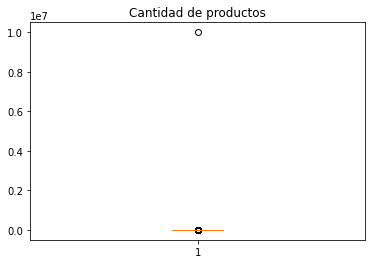

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

fig1, ax1 = plt.subplots()
ax1.set_title('Cantidad de productos')
ax1.boxplot(np.array(detallesOrdenes.select('Cantidad').collect()))

{'whiskers': [<matplotlib.lines.Line2D at 0x1503330cd48>,
 'caps': [<matplotlib.lines.Line2D at 0x15033311548>,
 'boxes': [<matplotlib.lines.Line2D at 0x1503330c4c8>],
 'medians': [<matplotlib.lines.Line2D at 0x15033318148>],
 'fliers': [<matplotlib.lines.Line2D at 0x150343ecc08>],
 'means': []}

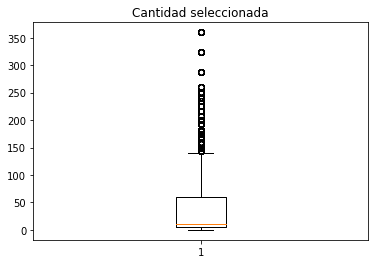

In [ ]:
fig1, ax1 = plt.subplots()
ax1.set_title('Cantidad seleccionada')

my_list = [float(i) for i in detallesOrdenes.select(f.collect_list('Cantidad_seleccionada')).first()[0]]
ax1.boxplot(my_list)

El análisis anterior es muy útil para variables de tipo numérico, sin embargo es incompleto para las variables de tipo caracter o las variables categoricas, por ende es necesario implementar nuestro propio código par obtener estadisticos como la moda y la mediana. A continuación obtenemos la moda para la variable Descripcion:

In [ ]:
detallesOrdenes.groupby("Descripcion").count().orderBy("count", ascending=False).show(5)

+--------------------+-----+
|         Descripcion|count|
+--------------------+-----+
|                   a| 3225|
|Halloween skull m...|  306|
|Large  replacemen...|  305|
|"The Gu" red shir...|  303|
|"The Gu" red shir...|  296|
+--------------------+-----+
only showing top 5 rows



## Análisis de calidad de datos
La calidad de los datos consiste en validar la idoneidad de los datos analizando varias dimensiones, entre las cuales resaltamos:
- Completitud: Datos que no existen o no se conocen
- Unicidad (Duplicidad): Datos que son idénticos en diferentes registros o registros con valores idénticos en atributos en los que no debería ocurrir
- Consistencia: Esta medida se define por la validez o integridad del dato, en la definición de su estructura, al interior de una fila o entre diferentes filas de la misma fuente o de diferentes fuentes. El manejo de unidades en los datos y el significado del dato son generadores de inconsistencias.
- Validez: a nivel de formato y de sentido de los datos más alla de sus valores

Para asegurar una calidad mínima de los datos en estas dimensiones hay que entender su origen y posteriormente realizar un proceso de validación de cada una de las dimensiones de perfilamiento que llevará a un entendimiento de los datos disponibles.


A continuación se definen dos funciones, la primera cuenta los valores vacios por columna de dataframe, la segunda retorna un diccionario de columnas con cardinalidad superior al 50%

Te invito a revisar los recursos de calidad de datos que hemos visto en el curso, a continuacion ejemplos daremos algunos ejemplos por cada dimensión para el caso del tutorial

### Unicidad y validez

La unicidad se revisó en la segunda regla de negocio y la validez se reviso en el perfilamiento general, en la regla de negocio 3 y en el análisis de la descripción al final de la sección de revisión de reglas de negocio

### Completitud y validez

In [ ]:
def contar_vacios(df):
    resultados = []
    for c in df.columns:
        vacios = df.filter(df[c].isNull()).count()
        if vacios!=0:
            print('número de vacíos para columna '+c+': '+str( vacios ))
            resultados.append(vacios)
    return resultados

def cardinalidad(df):
    resultado = {}
    for c in df.columns:
        cardinalidad = df.select(col(c)).distinct().count()
        if cardinalidad>=df.count()*0.5:
            resultado[c] = cardinalidad
    return resultado

In [ ]:
columnas_vacias_ordenes = contar_vacios(ordenes)
print('detalles de ordenes: ')
columnas_vacias_detalles = contar_vacios(detallesOrdenes)

número de vacíos para columna Seleccionado_por_ID_de_persona: 13570
número de vacíos para columna ID_de_pedido_pendiente: 79035
número de vacíos para columna Comentarios: 88258
número de vacíos para columna Instrucciones_de_entrega: 88258
número de vacíos para columna Comentarios_internos: 88258
número de vacíos para columna Seleccion_completada_cuando: 4347
detalles de ordenes: 
número de vacíos para columna Precio_unitario: 983
número de vacíos para columna Seleccion_completada_cuando: 982


In [ ]:
columnas_alta_cardinalidad_ordenes = cardinalidad(ordenes)
columnas_alta_cardinalidad_detalles = cardinalidad(detallesOrdenes)
columnas_alta_cardinalidad_ordenes, columnas_alta_cardinalidad_detalles

({'ID_de_pedido': 54145}, {'Detalle_orden_ID': 57981, 'ID_de_pedido': 38742})

Como podemos observar para las ordenes las columnas Seleccionado_por_ID_de_persona tiene 13750 vacios, ID_de_pedido_pendiente: 79035, Comentarios: 88258, Instrucciones_de_entrega: 88258, Comentarios_internos: 88258, Seleccion_completada_cuando: 4347, mientras que para los detalles de ordenes tenemos que las columnas con vacios son Precio_unitario: 983 y Seleccion_completada_cuando: 982. 

Respecto a cardinalidad, solo la columna Detalle_orden_ID tiene una cardinalidad superior al 50%.

### Consistencia
A nivel de consistencia algunos ejemplos de revisión son precios negativos, productos que aparecen en las ordenes pero que no esten registrados en la tabla de produtos. En nuestro caso vamos a verificar que todas las ordenes tengan detalle de orden y viceversa

In [ ]:
#consistencia: revisar genially: definicion de consistencia
ids_ordenes = set([x.ID_de_pedido for x in ordenes.select('ID_de_pedido').collect()])
ids_detalles = set([x.ID_de_pedido for x in detallesOrdenes.select('ID_de_pedido').collect()])

len(ids_ordenes-ids_detalles), len(ids_detalles-ids_ordenes)

(44359, 28956)

Como se puede observar hay una diferencia de 44.359 ordenes que no tienen detalles y hay 28.956 detalles que no tienen orden. Ninguno de los casos tiene sentido en el contexto de WideWorldImporters. Esta inconsistencia se notifica al negocio dado que no hay forma de conocer cuáles son los registros que pueden tener ids que no existen

## Herramientas para facilitar el entendimiento de datos

Algunas de las estadísticas antes desarrolladas pueden obtenerse por medio de herramientas como Pandas Profiling una herramienta muy útil, <b><i>Pero no perfecta ni completa</i></b>, es Pandas profiling que dado un conjunto de datos, nos muestra histogramas, estadísticas etc. A continuación guardamos el reporte en html

In [ ]:
reporte = ProfileReport(ordenes.toPandas())
reporte.to_file(PATH+"reporte_prefilamiento.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Lo primero que hay que notar es que hay 3 secciones principales. La primera es un resumen, la segunda es un análisis por cada variable y luego tenemos interacciones y correlaciones entre variables. 

Seccion general del reporte:
1. Tenemos 14 variables y 88.258 registros (es decir, ordenes), de las cuales 7 son numericas, 2 categoricas, 1 booleana, 1 datetime y 3 no soportadas (la herramienta entiende tipo de variable como tipo de dato, asi que la información que nos da no es necesariamente correcta en este aspecto).

2. En los datos hay 29.3% de datos vacíos, (conclusión)

3. El archivo ocupa en memoria 7.5 MB

4. No hay registros duplicados

Sección de variables del reporte:

5. Note que para cada variable nos dan estadisticos como la media, mínimo y máximo asi como un histograma de distribución de la variable, para nuestros datos no observamos nada por fuera de lo comun. (Como valores extremos)

6. La variable ID_de_pedido tiene 61.3% de valores distintos, es decir, es una variable con alta cardinalidad. Este tipo de variables no aportan a las relaciones entre filas o columnas, por lo que suelen no ser útiles a la hora de hacer análitica.

7. La variable ID_cliente tiene solo el 0,8% de valores distintos, es decir que las ordenes que tenemos parecen ser de pocos clientes, pero que podrían ser recurrentes o fieles

8. Hay 10 empleados en los datos de ordenes

9. Seleccionado_por_ID_persona tiene 15,4% de datos vacíos, no es muy alto pero podríamos eliminarla si no es importante. Preguntar al negocio

10. ID_de_pedido_pendiente tiene un porcentaje de 89,5% de valores vacíos, es casi constante y las columnas constantes no aportan a los análisis, preguntar al negocio si hay algún inconveniente en borrar esta columna

11. Hay 1512 Fecha_de_pedido distintos, siendo el 3 de febrero del 2015 una de las fechas con más número de ordenes

12. Fecha_de_entrega_esperada y Seleccion_completada_cuando tienen alta cardinalidad

Sección de interacciones y correlaciones:

Parecen haber columnas con correlaciones(Spearman) iguales a 1, esto significa que ambas columnas representan la misma información, idealmente no queremos columnas "repetidas", un ejemplo es ID_cliente y ID_de_persona_de_contacto, decidimos preguntarle al negocio si es necesario mantener ambas columnas

<b>Cabe aclarar que un pandas profiling sin interpretación no es suficiente como análisis para realizar el entendimiento de los datos.

Así mismo, recuerde que si es necesario, se debe utilizar otra herramienta (código, visualizaciones, etc) para poder completar el análisis estadístico.</b>

### Algunas gráficas utiles: Diagrama de caja, dispersion, histogramas para entender las distribuciones de las variables

Generalmente las gráficas se emplean para entender la distribución de cada variable, también sirven para visualizar la relación entre 2 o más variables

Algunas gráficas útiles son los histogramas, disepersión, diagramas de caja. Hay varias maneras de implementarlos, con paquetes como matplotlib o pandas, con funciones propias de pyspark, etc, a continuacón mostramos cómo hacerlo a travez de pandas

array([[<AxesSubplot:title={'center':'Cantidad_seleccionada'}>]],
      dtype=object)

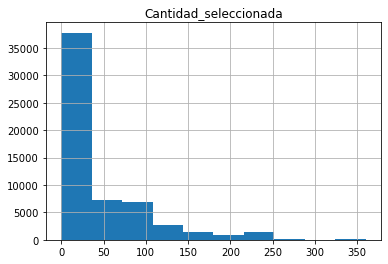

In [ ]:
#para valores extremos(subir a calidad)
detallesOrdenes.toPandas().hist(column='Cantidad_seleccionada')

In [ ]:
cantidades = detallesOrdenes.groupby("Cantidad").count().orderBy("count", ascending=False)

Como se puede observar, el método retorna un dataframe, que vamos a usar para obtener dos arreglos, uno con el rango de cada una de las barras y otro con la cantidad de registros por rango. Se puede usar Matplotlib para graficar esta información:

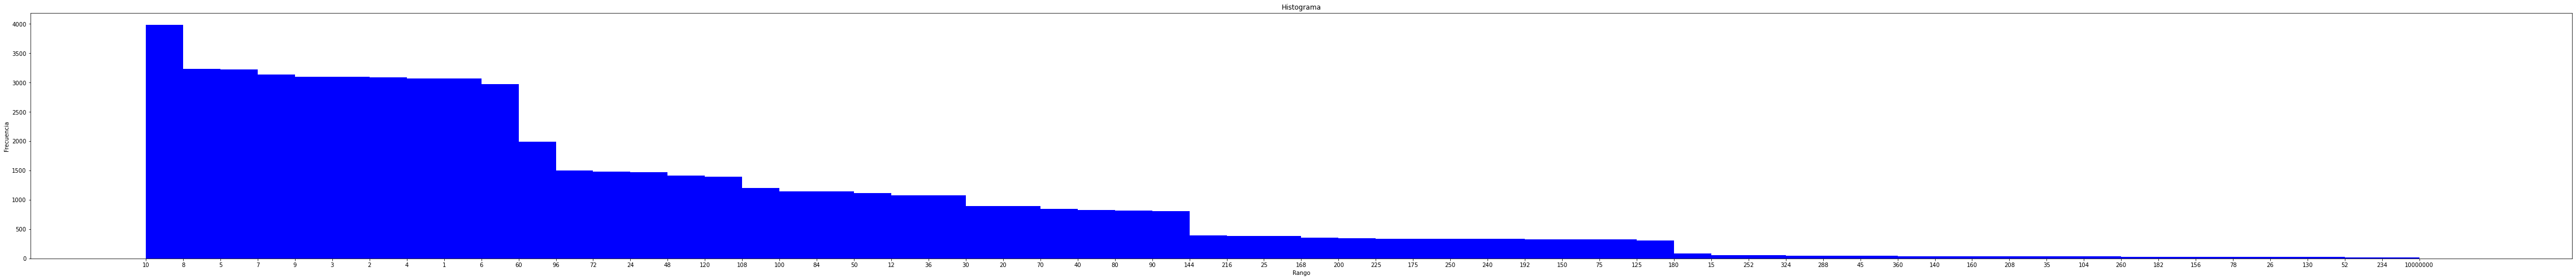

In [ ]:
def plotHistogramData(data):
    binSides, binCounts = [row[0] for row in data.collect()], [row[1] for row in data.collect()]
    binSides = [round(i, 2) for i in binSides]
    N = len(binCounts)
    ind = np.arange(N)
    width = 1

    fig, ax = plt.subplots()
    rects1 = ax.bar(ind+0.5, binCounts, width, color='b')
    
    fig.set_size_inches(1.3*N, 8)

    ax.set_ylabel('Frecuencia')
    ax.set_xlabel('Rango')
    ax.set_title('Histograma')
    ax.set_xticks(np.arange(N))
    ax.set_xticklabels(binSides)

    plt.show()

plotHistogramData(cantidades)

El diagrama de dispersion, nos muestra los datos para dos variables en forma de puntos y es muy útil para entender la relación entre dichas variables

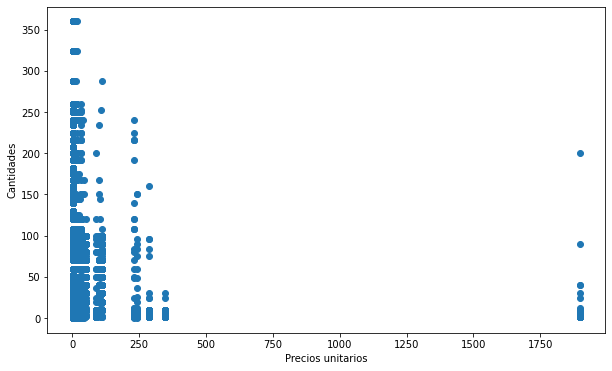

In [ ]:
unitPrices = [row['Precio_unitario'] for row in detallesOrdenes.select(col('Precio_unitario')).collect()]
quantities = [row['Cantidad_seleccionada'] for row in detallesOrdenes.collect()]

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x = unitPrices, y = quantities)
plt.xlabel("Precios unitarios")
plt.ylabel("Cantidades")

plt.show()

### Otras opciones de exploración
PySpark también da la opción de crear tablas de pivotes. En el siguiente ejemplo, se muestra cómo hacer una tabla que permite ver cuántas ordenes hay por cada <i>Fecha_de_pedido</i> y por cada <i>ID_de_vendedor</i>, es decir por fecha y por empleado cuantas ordenes existen:

In [ ]:
ordenes.groupBy('Fecha_de_pedido').pivot('ID_de_vendedor').count().show()

+---------------+----+---+---+----+----+----+---+----+---+----+
|Fecha_de_pedido|   2|  3|  6|   7|   8|  13| 14|  15| 16|  20|
+---------------+----+---+---+----+----+----+---+----+---+----+
|     2014-12-13|   7|  8|  7|   5|   3|   6|  7|   6|  2|   6|
|     2014-05-27|   6|  7|  8|   6|   2|  11|  6|   5| 13|   6|
|     2014-02-22|   6|  4|  2|   6|   4|   3|  2|null| 11|   7|
|     2015-05-01|  22| 13| 17|   2|  14|  13|  9|  11| 19|  16|
|    Feb 27,2014|   5|  3|  6|   1|   3|null|  3|   3|  7|   1|
|     2015-02-09|   2| 13| 15|  18|   8|   6|  6|   7| 15|  15|
|    Sep 21,2015|   2|  6|  7|   6|   2|   2|  3|   3|  3|   2|
|     2014-07-14|  13| 10| 15|   7|   5|  13| 15|  10| 17|  12|
|    Jul 26,2014|   2|  2|  3|   3|   1|   1|  3|null|  1|   2|
|    May 14,2016|null|  3|  2|   5|   1|   4|  3|null|  1|   3|
|    Aug 22,2015|   1|  1|  2|   4|null|   2|  2|   2|  5|   1|
|     2014-12-11|  13| 18|  4|   4|   9|  10|  2|  11|  5|   2|
|     2015-02-27|  19| 14| 10|  10|  22|

Otro análisis muy útil es el de la correlación lineal entre dos variables, para ver la matriz de correlacion que mide esta dependencia o la fuerza de la relación lineal entre dos variables vamos a usar pandas, la interpretación es que si entre dos variables A y B  el valor obtenido es cercano a -1 o a 1, se interpreta como que A y B contienen la misma información y por ende no es necesario mantener ambas columnas

In [ ]:
corr = detallesOrdenes.toPandas().corr(method='pearson')
corr.style.background_gradient(cmap='coolwarm')

C:\ProgramData\Anaconda3\envs\Tutoriales\lib\site-packages\pandas\io\formats\style.py:2813: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
C:\ProgramData\Anaconda3\envs\Tutoriales\lib\site-packages\pandas\io\formats\style.py:2814: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,Detalle_orden_ID,ID_de_pedido,ID_Producto,ID_Tipo_Paquete,Cantidad,Cantidad_seleccionada
Detalle_orden_ID,1.000000,0.052772,0.022949,nan,0.003160,0.003761
ID_de_pedido,0.052772,1.000000,-0.007438,nan,-0.003613,-0.008976
ID_Producto,0.022949,-0.007438,1.000000,nan,0.002252,0.513602
ID_Tipo_Paquete,nan,nan,nan,nan,nan,nan
Cantidad,0.003160,-0.003613,0.002252,nan,1.000000,-0.001033
Cantidad_seleccionada,0.003761,-0.008976,0.513602,nan,-0.001033,1.000000


## Conclusiones/resultados


**Conclusiones generales:**

1. En la tabla de ordenes tenemos información **relacionada con el cliente, el empleado y con la órden**. Por otra parte, en los detalles de ordenes se tiene **información del pedido y del producto**
2. Una fila de órdenes representa la órden realizada por un cliente y atendida por un empleado. Mientras que el detalle de órden coincide con su nombre y contiene el detalle de cada producto solicitado en una órden.
3. ¿cuál es la diferencia entre cantidad y cantidad seleccionada?

**Conclusiones de reglas de negocio:**

1. La regla 1 no es completamente cierta, pues en los datos no hay ningun registro con tasa_de_impuesto de 10%, es necesario pedir aclaraciones al negocio en relación a este descubrimiento
2. La regla 2 no es cierta dado que el número de registros no parece coincidir con el número dado por el negocio, Hay 14.079 ordenes completamente repetidas y 258 registros que representan el mismo detalle de orden pero con valores distintos, los primeros se pueden eliminar, pero ¿qué deberíamos hacer con los segundos?
3. Los datos comienzan en enero 1 de 2014, sin embargo la regla 2 nos dice que debería ser desde 2013, ¿es un error o faltan datos?
4. Algunos formatos de fecha no coinciden con el dado en la regla 3, por ejemplo del atributo Fecha_de_pedido hay 20 mil registros que no tienen ese formato. En este caso el cambio de formato se puede implementar, ¿estan de acuerdo?
5. La descripcion de algunos productos es "a", ¿esto es correcto?

**Conclusiones de calidad:**

1. Las columnas Comentarios, Instrucciones_de_entrega y Comentarios_internos tienen un conteo igual a 0, es decir son columnas vacías por lo que se pueden eliminar
2. Vemos por ejemplo que el valor máximo de Cantidad indica valores anómalos o extremos, pues en su percentil 75% el valor máximo era 60, es decir, para el 75% de los datos, el valor de Cantidad no superaba el 70, pero el valor máximo es de 10 millones
3. Observamos que la columna ID_Tipo_Paquete solo toma el valor 7, que podría ser o no un error, se notifica al negocio.
4. Para las ordenes las columnas Seleccionado_por_ID_de_persona tiene 16662 vacios, ID_de_pedido_pendiente: 96905, Comentarios: 108291, Instrucciones_de_entrega: 108291, Comentarios_internos: 108291, Seleccion_completada_cuando: 5276, mientras que para los detalles de ordenes tenemos que las columnas con vacios son Precio_unitario: 7038 y Seleccion_completada_cuando: 3186.
5. Respecto a cardinalidad, solo la columna Detalle_orden_ID tiene una cardinalidad superior al 50%.
6. Como se puede observar hay una diferencia de 44.359 ordenes que no tienen detalles y hay 28.956 detalles que no tienen orden. Ninguno de los casos tiene sentido en el contexto de WideWorldImporters. ¿Tienen alguna forma de identificar cual detalle corresponde a cual orden?

**Usando herramientas:**

Seccion general del reporte:
1. Tenemos 14 variables y 88.258 registros (es decir, ordenes), de las cuales 7 son numericas, 2 categoricas, 1 booleana, 1 datetime y 3 no soportadas (la herramienta entiende tipo de variable como tipo de dato, asi que la información que nos da no es necesariamente correcta en este aspecto).

2. En los datos hay 29.3% de datos vacíos, (conclusión)

3. El archivo ocupa en memoria 7.5 MB

4. No hay registros duplicados

Sección de variables del reporte:

5. Note que para cada variable nos dan estadisticos como la media, mínimo y máximo asi como un histograma de distribución de la variable, para nuestros datos no observamos nada por fuera de lo comun. (Como valores extremos)

6. La variable ID_de_pedido tiene 61.3% de valores distintos, es decir, es una variable con alta cardinalidad. Este tipo de variables no aportan a las relaciones entre filas o columnas, por lo que suelen no ser útiles a la hora de hacer análitica.

7. La variable ID_cliente tiene solo el 0,8% de valores distintos, es decir que las ordenes que tenemos parecen ser de pocos clientes, pero que podrían ser recurrentes o fieles

8. Hay 10 empleados en los datos de ordenes

9. Seleccionado_por_ID_persona tiene 15,4% de datos vacíos, no es muy alto pero podríamos eliminarla si no es importante. Preguntar al negocio

10. ID_de_pedido_pendiente tiene un porcentaje de 89,5% de valores vacíos, es casi constante y las columnas constantes no aportan a los análisis, preguntar al negocio si hay algún inconveniente en borrar esta columna

11. Hay 1512 Fecha_de_pedido distintos, siendo el 3 de febrero del 2015 una de las fechas con más número de ordenes

12. Fecha_de_entrega_esperada y Seleccion_completada_cuando tienen alta cardinalidad

Sección de correlación:

13. Parecen haber columnas con correlaciones(Spearman) iguales a 1, esto significa que ambas columnas representan la misma información, idealmente no queremos columnas "repetidas", un ejemplo es ID_cliente y ID_de_persona_de_contacto, decidimos preguntarle al negocio si es necesario mantener ambas columnas

**Conclusiones de consultoria**

![Requerimiento](./Requerimiento.png)

Teniendo en cuenta el requerimiento de WWI, consideramos que es posible llevar a cabo una solucióon pues contamos con la información necesaria especificada en el análisis requerido, sin embargo es necesario realizar correcciones a los datos y obtener aclaraciones de parte del negocio para entender completamente la necesidad de negocio

Para comprobar su comprensión de esta sección, lo invitamos a responder la pregunta:

    ¿Qué funcionalidades de PySpark puedo utilizar para realizar el entendimiento de datos y cómo las puedo utilizar?
    
Como parte de nuestro trabajo es preveer posibles soluciones a las conclusiones de perfilamiento, por ende lo invitamos a responder:

    ¿Qué métodos podría utilizar para reemplazar los valores nulos de una columna por el promedio de la misma?

# 5. Tarea

En este proyecto de analítica 1.0 para Wide World Importers (WWI), nos enfocaremos en la fase de entendimiento de datos para la tabla movimientos (movimientosCopia). El objetivo estratégico es optimizar el manejo de inventario de los productos a partir de las transacciones históricas.

### Perfilamiento de datos

### Información sobre los datos:

* **Cantidad máxima de productos:** La cantidad máxima de productos movidos es 50 millones por transacción.
* **Volumetría histórica:** Existen 236.668 movimientos de producto realizados desde 2013.
* **Relación de clientes:** Los movimientos están relacionados con 228.265 clientes.
* **Formato de fechas:** El formato de fechas manejado es `YYYY-MM-DD HH:MM:SS`.
* **Maestro de proveedores:** Actualmente tenemos 13 proveedores.

## 1. Conexión y acceso a los datos

In [22]:
#Definir tabla
sql_movimientos = 'WWImportersTransactional.movimientosCopia'


In [23]:
movimientos = obtener_dataframe_de_bd(
    db_connection_string,
    sql_movimientos,
    db_user,
    db_psswd
)

In [24]:
movimientos.show(10, False)

+---------------------+----------+-----------------+---------+---------+-----------+---------------+----------------+--------+
|TransaccionProductoID|ProductoID|TipoTransaccionID|ClienteID|InvoiceID|ProveedorID|OrdenDeCompraID|FechaTransaccion|Cantidad|
+---------------------+----------+-----------------+---------+---------+-----------+---------------+----------------+--------+
|118903               |217       |10               |476.0    |24904.0  |           |               |Apr 25,2014     |-40.0   |
|286890               |135       |10               |33.0     |60117.0  |           |               |Dec 10,2015     |-7.0    |
|285233               |111       |10               |180.0    |59768.0  |           |               |Dec 04,2015     |-2.0    |
|290145               |213       |10               |33.0     |60795.0  |           |               |Dec 23,2015     |-3.0    |
|247492               |90        |10               |55.0     |51851.0  |           |               |Jul 27,2015

Como puede observar en la tabla de **movimientos**, tenemos información **relacionada con el producto, la transacción comercial (clientes/proveedores) y la operación logística**. La información del producto es su identificador <i>ProductoID</i>. La información de la transacción comercial se divide según el tipo de operación: para el caso de ventas a clientes, se cuenta con el identificador del cliente <i>ClienteID</i> y el identificador de la factura <i>InvoiceID</i>; mientras que para el caso de abastecimiento con proveedores, se dispone del identificador del proveedor <i>ProveedorID</i> y el identificador de la orden de compra <i>OrdenDeCompraID</i>. La información de la operación logística es: el identificador único del movimiento <i>TransaccionProductoID</i>, el motivo o tipo de operación <i>TipoTransaccionID</i>, la fecha en la que se realizó el registro <i>FechaTransaccion</i> y la <i>Cantidad</i> de artículos movidos, la cual indica una entrada al almacén si su valor es positivo o una salida si es negativo.

**¿Qué significa una fila en esta tabla?**

Una fila de la tabla `movimientos` representa una **transacción o mutación física individual en el inventario** de un producto específico (<i>ProductoID</i>), ocurrida en un momento exacto (<i>FechaTransaccion</i>). En ella se detalla si la operación fue una entrada o una salida de mercancía mediante un valor numérico (<i>Cantidad</i>), vinculando su justificación comercial a través de un tipo de movimiento (<i>TipoTransaccionID</i>) junto con su respectivo documento de soporte.

In [27]:
print((movimientos.count(), len(movimientos.columns)))

(204292, 9)


In [25]:
movimientos.printSchema()

root
 |-- TransaccionProductoID: integer (nullable = true)
 |-- ProductoID: integer (nullable = true)
 |-- TipoTransaccionID: integer (nullable = true)
 |-- ClienteID: double (nullable = true)
 |-- InvoiceID: double (nullable = true)
 |-- ProveedorID: string (nullable = true)
 |-- OrdenDeCompraID: string (nullable = true)
 |-- FechaTransaccion: string (nullable = true)
 |-- Cantidad: double (nullable = true)



## 2. Entendimiento General de los Datos

A partir de la ejecución inicial en PySpark, registramos la volumetría física de la fuente compartida:

* **Número de registros (Filas):** 204,292
* **Número de variables (Columnas):** 9



### Esquema y Tipos de Datos Inferidos

Al ejecutar `movimientos.printSchema()`, se identifican las siguientes columnas esenciales:

* **a. TransaccionProductoID** *(Integer / Variable Categórica-Identificador)*: Clave primaria de la transacción.
* **b. ProductoID** *(Integer / Variable Categórica-Identificador)*: Identificador del artículo de stock.
* **c. TipoTransaccionID** *(Integer / Variable Categórica)*: Código del motivo del movimiento.
* **d. ClienteID y InvoiceID** *(Double-Float / Variables Categóricas)*: Relación con la venta.
* **e. ProveedorID y OrdenDeCompraID** *(String-Null / Variables Categóricas)*: Relación con el abastecimiento (compras).
* **f. FechaTransaccion** *(Timestamp-String / Variable Temporal)*: Momento exacto del registro.
* **g. Cantidad** *(Double-Float / Variable Numérica Continua)*: Magnitud del movimiento físico en el almacén.


## 3. Revisión de Reglas de Negocio

### **Cantidad máxima de productos:** La cantidad máxima de productos movidos es 50 millones por transacción.

In [ ]:
# --- VALIDACIÓN DEL SUPUESTO DE LOS 50 MILLONES ---
# Vamos a revisar los valores de la columna Cantidad para ver qué tan grandes son los movimientos.

from pyspark.sql.functions import col, abs

# Primero miramos los datos ordenados de mayor a menor en valor absoluto
print("Top 5 movimientos más grandes (en magnitud):")
movimientos.withColumn("Magnitud", abs(col("Cantidad"))).orderBy("Magnitud", ascending=False).show(5)

print("Estadísticos básicos de la columna Cantidad:")
movimientos.select("Cantidad").summary("min", "max").show()

limite_negocio = 50000000
registros_anomalos = movimientos.filter(abs(col("Cantidad")) > limite_negocio).count()

print("Resultado de la validación:")
print("Número de transacciones que superan los 50 millones:", registros_anomalos)

Top 5 movimientos más grandes (en magnitud):


+---------------------+----------+-----------------+---------+---------+-----------+---------------+----------------+--------+--------+
|TransaccionProductoID|ProductoID|TipoTransaccionID|ClienteID|InvoiceID|ProveedorID|OrdenDeCompraID|FechaTransaccion|Cantidad|Magnitud|
+---------------------+----------+-----------------+---------+---------+-----------+---------------+----------------+--------+--------+
|               335504|       193|               11|      0.0|      0.0|        7.0|         2069.0|     May 30,2016| 67368.0| 67368.0|
|               335845|       193|               11|      0.0|      0.0|        7.0|         2072.0|     May 31,2016| 67272.0| 67272.0|
|               334872|       193|               11|      0.0|      0.0|        7.0|         2067.0|     May 27,2016| 67200.0| 67200.0|
|               334385|       193|               11|      0.0|      0.0|        7.0|         2065.0|     May 26,2016| 66840.0| 66840.0|
|               333714|       193|              

+-------+--------+
|summary|Cantidad|
+-------+--------+
|    min|  -360.0|
|    max| 67368.0|
+-------+--------+



Resultado de la validación:
Número de transacciones que superan los 50 millones: 0


* **Conclusión:** > **El supuesto se cumple con éxito.** El análisis exploratorio muestra que el valor máximo registrado en la columna `Cantidad` es de apenas 67.368 unidades, y el número de transacciones que superan los 50 millones es exactamente cero. Además, se detectaron valores negativos (mínimo de -360.0).
> 
> **Recomendación Académica / Negocio:** Es evidente que existe una confusión en las unidades de medida o en la interpretación del indicador por parte del negocio (pudo haberse confundido la cantidad de productos con montos monetarios totales). Se recomienda solicitar una aclaración para unificar el criterio. Asimismo, los valores negativos deben ser validados, ya que metodológicamente podrían representar devoluciones de inventario o anulaciones de facturas que requieren un tratamiento especial en el modelo.

### **Volumetría histórica:** Existen 236.668 movimientos de producto realizados desde 2013 
### **Volumetría de clientes:** Los movimientos están relacionados con 228.265 clientes

In [ ]:
# --- VALIDACIÓN DE VOLUMETRÍA E HISTÓRICO ---

from pyspark.sql.functions import min, max

# 1. Contamos el total de filas que tiene el DataFrame actual
total_filas = movimientos.count()
print("Total de movimientos encontrados en la tabla:", total_filas)

# 2. Buscamos la fecha más vieja y la más nueva para revisar el año de inicio
fechas_extremo = movimientos.select(
    min("FechaTransaccion").alias("Fecha_Mas_Antigua"), 
    max("FechaTransaccion").alias("Fecha_Mas_Reciente")
).first()

print("El movimiento más antiguo registrado es del:", fechas_extremo["Fecha_Mas_Antigua"])
print("El movimiento más reciente registrado es del:", fechas_extremo["Fecha_Mas_Reciente"])


Total de movimientos encontrados en la tabla: 204292


El movimiento más antiguo registrado es del: 2013-12-31 07:00:00.0000000
El movimiento más reciente registrado es del: Sep 30,2015


### Volumetría Histórica de Movimientos
* **Conclusión:** > **El supuesto NO se cumple con éxito.** No existen más de 205k registros totales en la tabla actual (el conteo real es de exactamente 204.292 filas), lo que evidencia un faltante de información frente a la expectativa inicial.
* **Recomendación:** Se sugiere revisar los parámetros de extracción en la base de datos fuente, ya que la diferencia de registros (cercana al 13.6%) podría deberse a un truncamiento en la consulta SQL original o a la exclusión involuntaria de alguna bodega. Es necesario solicitar una nueva extracción para evitar sesgos en el análisis.



### Volumetría de Clientes Únicos
* **Conclusión:** > **El supuesto NO se cumple con éxito.** No es posible tener 228k clientes únicos en una tabla que solo registra 204.292 filas totales; la cifra informada por el negocio debe corresponder al catálogo general y no a la actividad de esta tabla.
* **Recomendación:** Se recomienda aclarar con el negocio la definición operativa de esta variable. El dato entregado parece corresponder al maestro global de clientes y no a los clientes activos. Se propone realizar un cruce (`JOIN`) en la fase de ETL para segmentar la demanda real.

### **Formato de fecha:** El formato de fechas manejado es YYYY-MM-DD HH:MM:SS

In [31]:
# --- VALIDACIÓN DEL FORMATO DE FECHAS ---

# 1. Traemos los primeros 5 registros de la columna FechaTransaccion
print("Muestra de los datos reales en la columna FechaTransaccion:")
movimientos.select("FechaTransaccion").show(5, truncate=False)


Muestra de los datos reales en la columna FechaTransaccion:


+----------------+
|FechaTransaccion|
+----------------+
|Apr 25,2014     |
|Dec 10,2015     |
|Dec 04,2015     |
|Dec 23,2015     |
|Jul 27,2015     |
+----------------+
only showing top 5 rows



In [39]:
# --- TRANSFORMACIÓN DEL FORMATO DE FECHAS ---
# Convertimos el texto 'Apr 25,2014' al formato estándar 'YYYY-MM-DD HH:MM:SS'

from pyspark.sql.functions import col, to_timestamp, date_format

movimientos_limpio = movimientos.withColumn("Fecha_Estandar", date_format(to_timestamp(col("FechaTransaccion"), "MMM dd,yyyy"), "yyyy-MM-dd HH:mm:ss"))

print("Comparativa de formato original vs. formato transformado:")
movimientos_limpio.select("FechaTransaccion", "Fecha_Estandar").show(5, truncate=False)

Comparativa de formato original vs. formato transformado:


+----------------+-------------------+
|FechaTransaccion|Fecha_Estandar     |
+----------------+-------------------+
|Apr 25,2014     |2014-04-25 00:00:00|
|Dec 10,2015     |2015-12-10 00:00:00|
|Dec 04,2015     |2015-12-04 00:00:00|
|Dec 23,2015     |2015-12-23 00:00:00|
|Jul 27,2015     |2015-07-27 00:00:00|
+----------------+-------------------+
only showing top 5 rows



* **Conclusión:** > **El supuesto NO se cumple con éxito.** La columna `FechaTransaccion` presenta un formato de texto completamente diferente (`MMM DD, YYYY`) y no incluye la estampa de tiempo (horas, minutos y segundos).
> 
> **Acción y Recomendación:** De forma proactiva, se desarrolló e implementó la transformación técnica en PySpark para estandarizar e indexar la columna al formato solicitado por la organización. Sin embargo, **se requiere una aclaración por parte del negocio** y se recomienda gestionar que se modifique el formato directamente desde la fuente de origen, asegurando así la integridad y consistencia de los datos desde la extracción inicial.

### **Conteo de Proveedores:** Actualmente tenemos 13 proveedores

In [37]:
# --- VALIDACIÓN DEL SUPUESTO DE PROVEEDORES ---

from pyspark.sql.functions import col, countDistinct

# 1. Contar cuántos ProveedorID únicos existen (ignorando nulos)
proveedores_unicos = movimientos.select(countDistinct("ProveedorID")).collect()[0][0]
print("Cantidad de Proveedores ÚNICOS detectados en la tabla:", proveedores_unicos)



Cantidad de Proveedores ÚNICOS detectados en la tabla: 4


In [38]:
# --- CONTEO DE MOVIMIENTOS POR CATEGORÍA ---
from pyspark.sql.functions import col

print("Distribución de registros por categoría de ProveedorID:")
movimientos.groupBy("ProveedorID") \
           .count() \
           .orderBy("count", ascending=False) \
           .show()

Distribución de registros por categoría de ProveedorID:


+-----------+------+
|ProveedorID| count|
+-----------+------+
|           |197182|
|        4.0|  4832|
|        7.0|  2267|
|        1.0|    11|
+-----------+------+



* **Conclusión:** >  **El supuesto NO se cumple con éxito.** Tras agrupar y analizar la columna `ProveedorID`, únicamente se lograron identificar **3 IDs de proveedores activos** (`1.0`, `4.0` y `7.0`). Además, la gran mayoría de los registros (197.182 filas) se encuentran completamente en blanco (`null`).
> 
> **Recomendación y Acción:** Si bien la ausencia de estos datos es lógica —dado que la mayoría de los movimientos corresponden a transacciones con clientes (ventas) que de manera natural no requieren un código de proveedor—, el volumen de nulos representa un porcentaje sumamente alto de la tabla. Por lo tanto, se recomienda **solicitar una aclaración formal al negocio** para confirmar si este comportamiento es el esperado o si existe un sesgo en la extracción de la información de compras y reabastecimiento.

## 4. Analisis Descriptivo

In [41]:
# --- FASE DESCRIPTIVA: ESTADÍSTICOS GENERALES ---

print("Tabla de Resumen Estadístico Descriptivo Global (Summary):")
movimientos.summary().show()

Tabla de Resumen Estadístico Descriptivo Global (Summary):


+-------+---------------------+------------------+-------------------+------------------+-----------------+-----------------+------------------+--------------------+-----------------+
|summary|TransaccionProductoID|        ProductoID|  TipoTransaccionID|         ClienteID|        InvoiceID|      ProveedorID|   OrdenDeCompraID|    FechaTransaccion|         Cantidad|
+-------+---------------------+------------------+-------------------+------------------+-----------------+-----------------+------------------+--------------------+-----------------+
|  count|               204292|            204292|             204292|            204292|           204292|           204292|            204292|              204292|           204292|
|   mean|   212458.04047637695|110.70090850351458| 10.035253460732676| 517.3252941867523|42957.26929590978|4.951898734177215|1345.9973277074544|                NULL|719.4997650421946|
| stddev|    71352.37579752573| 63.49014746219581|0.18563716955046372|353.501369

Después de correr el `.summary()`, Spark procesa todo como si fueran números continuos, pero la realidad es que casi todas son **variables categóricas** (`ProductoID`, `TipoTransaccionID`, `ClienteID`, `InvoiceID`, `ProveedorID`). No tiene sentido mirarles la media o la desviación estándar, pero revisando los mínimos y máximos salen los siguientes hallazgos:

* El `ClienteID` arranca en `0` (Suponiendo que es una Venta anónima). Lo curioso es que `InvoiceID` (facturas) también arranca en `0` y las columnas de compras (`ProveedorID` y `OrdenDeCompraID`) no muestran casi datos en los percentiles. **Conclusión:** La tabla está totalmente sesgada a registrar **ventas** y casi no tiene movimientos de compras.

* La variable `TipoTransaccionID` tiene una desviación de casi cero (`0.18`) y los percentiles 25%, 50% y 75% se clavan todos en el valor `10`. Esto significa que **el Tipo 10 domina toda la operación** y los otros tipos (que llegan hasta el 12) casi ni se usan.

* La columna Cantidad es la única variable numérica real y tiene el comportamiento más interesante:
    * El promedio da `719.5` unidades, pero si miras el percentil 75%, el valor es `-5.0`. ¡Esto significa que **más del 75% de los datos de la tabla son negativos**!
    * La gran mayoría de los registros de esta tabla son ajustes, devoluciones o cancelaciones (números negativos). 
    * La media da positiva y alta solo porque hay un valor máximo gigante de **67.368 unidades**. Ese outlier jala el promedio hacia arriba y camufla que el día a día de la tabla son movimientos negativos o muy pequeños.

In [42]:
# --- FASE DESCRIPTIVA: ANÁLISIS CATEGÓRICO ---

from pyspark.sql.functions import col, round as spark_round

total_movimientos = movimientos.count()

variables_especificas = ["ProductoID", "TipoTransaccionID", "ClienteID", "ProveedorID"]

for columna in variables_especificas:
    print(f"\n" + "="*50)
    print(f"DISTRIBUCIÓN DE FRECUENCIAS: {columna}")
    print("="*50)
    
    # Agrupamos por la variable, contamos, calculamos % y ordenamos descendentemente
    movimientos.groupBy(columna) \
               .count() \
               .withColumn("Porcentaje (%)", spark_round((col("count") / total_movimientos) * 100, 2)) \
               .orderBy("count", ascending=False) \
               .show(10, truncate=False)


DISTRIBUCIÓN DE FRECUENCIAS: ProductoID


+----------+-----+--------------+
|ProductoID|count|Porcentaje (%)|
+----------+-----+--------------+
|80        |1488 |0.73          |
|95        |1477 |0.72          |
|184       |1339 |0.66          |
|86        |1318 |0.65          |
|193       |1312 |0.64          |
|204       |1307 |0.64          |
|77        |1300 |0.64          |
|78        |1296 |0.63          |
|98        |1272 |0.62          |
|13        |986  |0.48          |
+----------+-----+--------------+
only showing top 10 rows


DISTRIBUCIÓN DE FRECUENCIAS: TipoTransaccionID


+-----------------+------+--------------+
|TipoTransaccionID|count |Porcentaje (%)|
+-----------------+------+--------------+
|10               |197136|96.5          |
|11               |7110  |3.48          |
|12               |46    |0.02          |
+-----------------+------+--------------+


DISTRIBUCIÓN DE FRECUENCIAS: ClienteID


+---------+-----+--------------+
|ClienteID|count|Porcentaje (%)|
+---------+-----+--------------+
|0.0      |7156 |3.5           |
|980.0    |409  |0.2           |
|810.0    |401  |0.2           |
|804.0    |395  |0.19          |
|149.0    |395  |0.19          |
|954.0    |395  |0.19          |
|185.0    |391  |0.19          |
|953.0    |389  |0.19          |
|438.0    |385  |0.19          |
|558.0    |385  |0.19          |
+---------+-----+--------------+
only showing top 10 rows


DISTRIBUCIÓN DE FRECUENCIAS: ProveedorID


+-----------+------+--------------+
|ProveedorID|count |Porcentaje (%)|
+-----------+------+--------------+
|           |197182|96.52         |
|4.0        |4832  |2.37          |
|7.0        |2267  |1.11          |
|1.0        |11    |0.01          |
+-----------+------+--------------+



Tras calcular el volumen y la participación porcentual de las cuatro variables específicas, se identifican patrones clave sobre el comportamiento operativo y la estructura del conjunto de datos:

 1. `ProductoID`
* A diferencia de otras variables, los productos más vendidos tienen una participación muy baja sobre el total de la tabla. El producto líder (`ID 80`) apenas representa el **0.73%** de los movimientos, seguido muy de cerca por el `ID 95` con **0.72%**.

* Esto demuestra que el negocio no depende de un único producto "estrella" que monopolice la demanda, sino que cuenta con un portafolio altamente diversificado donde las ventas se distribuyen de manera atomizada entre múltiples referencias.

 2. `TipoTransaccionID`
* Los datos confirman matemáticamente el supuesto previo. El **Tipo de Transacción 10 concentra el 96.5% de los registros** (197.136 filas). La segunda categoría (`ID 11`) apenas alcanza el **3.48%**, y la tercera (`ID 12`) es prácticamente marginal con un **0.02%**.

* Existe una centralización casi total de la actividad en un solo tipo de movimiento, lo que sugiere que este código representa la operación principal del negocio (por ejemplo, facturación regular de ventas directas).

 3. `ClienteID`
* El análisis de frecuencias revela que el `ClienteID 0.0` representa el **3.5%** de toda la tabla (7.156 registros). El resto de los clientes individuales (como el `980.0` o `810.0`) no superan el **0.2%** de participación individual.

* Esto respalda la hipótesis de que el `ID 0.0` funciona como un comodín del sistema para ventas anónimas o clientes no registrados. Excluyendo este caso, la base de clientes real está sumamente fragmentada y ningún comprador individual genera un impacto significativo por sí solo en el volumen transaccional.

 4. `ProveedorID`
* El **96.52%** de las filas no registran un proveedor (aparecen en blanco). En el espectro restante, solo tres proveedores tienen actividad, liderados por el `ID 4.0` con un **2.37%** y el `ID 7.0` con un **1.11%**.

* Existe una coincidencia exacta entre el porcentaje de registros vacíos en proveedores (**96.52%**) y el volumen del Tipo de Transacción 10 (**96.5%**). Esto demuestra de forma contundente que dicha transacción corresponde estrictamente a salidas comerciales (ventas), dejando una participación muy reducida para los movimientos de compras o reabastecimiento en este set de datos.

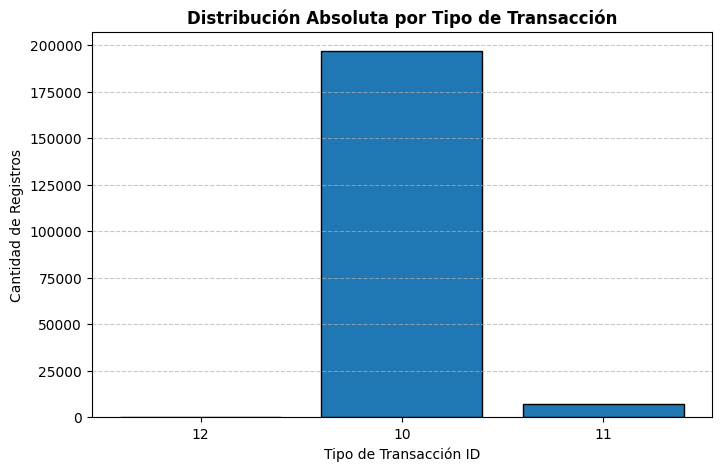

In [43]:
pdf_transacciones = movimientos.groupBy("TipoTransaccionID").count().toPandas()

plt.figure(figsize=(8, 5))
plt.bar(pdf_transacciones["TipoTransaccionID"].astype(str), pdf_transacciones["count"], color="#1f77b4", edgecolor='black')
plt.title("Distribución Absoluta por Tipo de Transacción", fontsize=12, fontweight='bold')
plt.xlabel("Tipo de Transacción ID")
plt.ylabel("Cantidad de Registros")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

* Al contrastar el gráfico de barras con la tabla de distribución de `ProveedorID`, el volumen de registros vacíos en proveedores (**197.182 filas**) coincide casi de manera exacta con el volumen total del Tipo de Transacción 10 (**197.136 filas**). Esta puede ser la prueba reina de que **el Tipo 10 representa la operación de ventas directas** a clientes y, por ende, carece lógicamente de un código de proveedor asociado.

* Por otro lado, el gráfico de barras de `TipoTransaccionID` expone de forma contundente la asimetría de la operación. Mientras que el Tipo 10 absorbe prácticamente toda la gráfica, las categorías 11 y 12 quedan reducidas a expresiones mínimas en el eje horizontal. Cualquier modelo analítico o predictivo que se construya con esta data estará condicionado al comportamiento del Tipo 10, por lo que es vital segmentar los datos antes de entrenar un algoritmo.

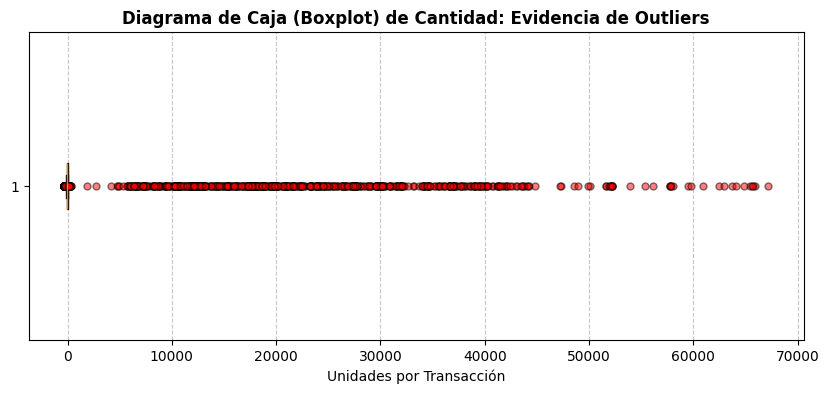

In [44]:
pdf_cantidad = movimientos.select("Cantidad").sample(False, 0.1, seed=42).toPandas()

plt.figure(figsize=(10, 4))
plt.boxplot(pdf_cantidad["Cantidad"], vert=False, patch_artist=True, 
            boxprops=dict(facecolor="#ff7f0e", color="black"),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))
plt.title("Diagrama de Caja (Boxplot) de Cantidad: Evidencia de Outliers", fontsize=12, fontweight='bold')
plt.xlabel("Unidades por Transacción")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Al observar el comportamiento gráfico del Boxplot para la variable `Cantidad`, se hace evidente la estructura atípica que se venía proyectando en los estadísticos descriptivos:

* La caja naranja (que encierra el 50% central de los datos, entre el percentil 25 y 75) se ve prácticamente como una línea vertical pegada al eje izquierdo. Esto confirma visualmente que **la gran masa de las transacciones maneja volúmenes extremadamente pequeños** (valores negativos y cercanos a cero), concentrando casi toda la densidad de los movimientos cotidianos.

* La interminable fila de puntos rojos que se extiende hacia la derecha representa valores atípicos. Esto demuestra gráficamente por qué la media de la columna se inflaba artificialmente hasta `719.5`: **el negocio tiene compras o movimientos corporativos gigantescos que rompen la distribución normal**.

* Al contrastar esta gráfica con la tabla de `ProveedorID` (donde vemos que el 96.5% son nulos y solo hay unas pocas filas con datos), cobra total sentido que los outliers sean tan distantes. Es muy probable que esos registros gigantes de más de 10.000 unidades pertenezcan de forma exclusiva a las pocas transacciones que sí tienen asignado un `ProveedorID` (compras de reabastecimiento masivo), mientras que la masa comprimida cerca a cero corresponde a las salidas por ventas al cliente final.

### Análisis de calidad de datos

### **COMPLETITUD**

In [52]:
# --- CALIDAD DE DATOS: COMPLETITUD POR COLUMNA ---
from pyspark.sql.functions import col, sum as spark_sum, when, round as spark_round

total_filas = movimientos.count()

expresiones_completitud = [spark_round((spark_sum(when(col(c).isNull() | (col(c) == ""), 0).otherwise(1)) / total_filas) * 100, 2).alias(c) for c in movimientos.columns]

print("Porcentaje de Completitud Real por Columna (%):")
movimientos.select(expresiones_completitud).show()

Porcentaje de Completitud Real por Columna (%):


+---------------------+----------+-----------------+---------+---------+-----------+---------------+----------------+--------+
|TransaccionProductoID|ProductoID|TipoTransaccionID|ClienteID|InvoiceID|ProveedorID|OrdenDeCompraID|FechaTransaccion|Cantidad|
+---------------------+----------+-----------------+---------+---------+-----------+---------------+----------------+--------+
|                100.0|     100.0|            100.0|    100.0|    100.0|       3.48|           3.48|           100.0|   100.0|
+---------------------+----------+-----------------+---------+---------+-----------+---------------+----------------+--------+



In [53]:
# --- CALIDAD DE DATOS: COMPLETITUD GLOBAL DE LA TABLA ---
from pyspark.sql.functions import col, sum as spark_sum, when

total_filas = movimientos.count()
total_columnas = len(movimientos.columns)
celdas_totales = total_filas * total_columnas
expresiones_celdas = [spark_sum(when(col(c).isNull() | (col(c) == ""), 0).otherwise(1)) for c in movimientos.columns]
fila_resultado = movimientos.select(expresiones_celdas).first()
celdas_completas = sum(fila_resultado)
completitud_global = round((celdas_completas / celdas_totales) * 100, 2)

print(f"Completitud Global de la Tabla: {completitud_global}%")

Completitud Global de la Tabla: 78.55%


In [54]:
# --- CALIDAD DE DATOS: COMPLETITUD POR FILA ---
from pyspark.sql.functions import col, when, round as spark_round
from functools import reduce
from operator import add

total_columnas = len(movimientos.columns)
expresiones_columnas = [when(col(c).isNull() | (col(c) == ""), 0).otherwise(1) for c in movimientos.columns]
movimientos_con_completitud_fila = movimientos.withColumn("Completitud_Fila_(%)", spark_round((reduce(add, expresiones_columnas) / total_columnas) * 100, 2))

print("Muestra de registros ordenados por MENOR completitud (Filas más vacías):")
movimientos_con_completitud_fila.select("TransaccionProductoID", "Completitud_Fila_(%)") \
                                .orderBy("Completitud_Fila_(%)", ascending=True) \
                                .show(10)

Muestra de registros ordenados por MENOR completitud (Filas más vacías):


+---------------------+--------------------+
|TransaccionProductoID|Completitud_Fila_(%)|
+---------------------+--------------------+
|               118903|               77.78|
|               286890|               77.78|
|               285233|               77.78|
|               290145|               77.78|
|               247492|               77.78|
|               157714|               77.78|
|               250024|               77.78|
|               200801|               77.78|
|               221525|               77.78|
|               295331|               77.78|
+---------------------+--------------------+
only showing top 10 rows



El análisis de completitud permite evaluar la presencia de valores nulos o vacíos en el set de datos a nivel global, por columnas y por registros individuales. Los resultados consolidan las siguientes conclusiones:

* **Completitud por Columna:** Siete de las nueve variables del DataFrame registran una completitud perfecta del **100.0%** (incluyendo llaves como `ProductoID` y variables operativas como `Cantidad` y `FechaTransaccion`). Sin embargo, las columnas `ProveedorID` y `OrdenDeCompraID` presentan una caída crítica, alcanzando apenas un **3.48%** de completitud real. Esto confirma que el **96.52%** de estas dos columnas está compuesto por datos faltantes.

* **Completitud por Fila :** Al revisar los registros más vacíos de la tabla, se evidencia que el límite inferior es del **77.78%** de completitud para todos ellos. Al tener la tabla 9 columnas en total, un **77.78%** significa que a estas filas les faltan exactamente 2 campos ($7 / 9 \approx 77.78\%$). **Hallazgo:** No existen filas totalmente vacías o corruptas; las filas "críticas" son simplemente aquellas que registran la operación de venta regular y, por ende, dejan vacíos los campos de `ProveedorID` y `OrdenDeCompraID`.

* **Completitud Global de la Tabla:** El indicador general se sitúa en un **78.55%**. Aunque en términos puramente estadísticos este porcentaje podría sugerir un problema de calidad generalizado, el desglose por columnas demuestra que la data está limpia en su estructura principal, y que el restante 21.45% de celdas vacías corresponde al sesgo natural de la operación hacia el flujo de ventas directas.

## **UNICIDAD**

In [ ]:
# --- CALIDAD DE DATOS: DIMENSIÓN DE UNICIDAD ---
from pyspark.sql.functions import col

# Guardamos el total de registros iniciales para los cálculos
total_registros = movimientos.count()

print(f"Total de registros en la fuente: {total_registros}\n")

# 1. Escenario A: Duplicidad Absoluta (Filas completamente idénticas)
total_unicos_absolutos = movimientos.distinct().count()
duplicados_absolutos = total_registros - total_unicos_absolutos
porcentaje_dup_absoluto = round((duplicados_absolutos / total_registros) * 100, 2)

print(f"--- Escenario A: Filas Completamente Repetidas ---")
print(f"Registros duplicados exactos: {duplicados_absolutos} ({porcentaje_dup_absoluto}%)")

# 2. Escenario B: Duplicidad en la Llave Primaria (TransaccionProductoID)
total_ids_unicos = movimientos.select("TransaccionProductoID").distinct().count()
ids_duplicados = total_registros - total_ids_unicos
porcentaje_dup_id = round((ids_duplicados / total_registros) * 100, 2)

print(f"\n--- Escenario B: Duplicidad en el Identificador (PK) ---")
print(f"IDs de transacción repetidos: {ids_duplicados} ({porcentaje_dup_id}%)")

# 3. Escenario C: Duplicidad Estructural en Facturas (InvoiceID)
# Contamos cuántas facturas únicas existen y cuántas veces se repiten en las filas
total_invoices_unicos = movimientos.select("InvoiceID").distinct().count()
filas_con_invoice_repetido = total_registros - total_invoices_unicos
porcentaje_dup_invoice = round((filas_con_invoice_repetido / total_registros) * 100, 2)

print(f"\n--- Escenario C: Repetición de Registros por InvoiceID ---")
print(f"Facturas únicas encontradas: {total_invoices_unicos}")
print(f"Filas asociadas a Invoices repetidos: {filas_con_invoice_repetido} ({porcentaje_dup_invoice}%)")

# 4. Escenario D: Entidades Repetidas con Distinto ID (Ignorando la PK)
columnas_sin_pk = [c for c in movimientos.columns if c != "TransaccionProductoID"]
total_unicos_sin_pk = movimientos.select(columnas_sin_pk).distinct().count()
duplicados_sin_pk = total_registros - total_unicos_sin_pk
porcentaje_dup_sin_pk = round((duplicados_sin_pk / total_registros) * 100, 2)

print(f"\n--- Escenario D: Entidades Repetidas con Distinto ID ---")
print(f"Transacciones idénticas (sin PK): {duplicados_sin_pk} ({porcentaje_dup_sin_pk}%)")

Total de registros en la fuente: 204292



--- Escenario A: Filas Completamente Repetidas ---
Registros duplicados exactos: 30633 (14.99%)



--- Escenario B: Duplicidad en el Identificador (PK) ---
IDs de transacción repetidos: 30633 (14.99%)



--- Escenario C: Repetición de Registros por InvoiceID ---
Facturas únicas encontradas: 51831
Filas asociadas a Invoices repetidos: 152461 (74.63%)



--- Escenario D: Entidades Repetidas con Distinto ID ---
Transacciones idénticas (sin PK): 30633 (14.99%)


Al evaluar el comportamiento de los registros repetidos bajo los cuatro escenarios propuestos, se identifican dos comportamientos de naturaleza completamente distinta:

* El hecho de que el **74.63%** de las filas estén asociadas a `InvoiceID` repetidos es **correcto y esperado**. Esto refleja la estructura natural de un negocio transaccional, donde una única factura consolidada ampara múltiples líneas de productos independientes. Contar con **51.831 facturas únicas** para los más de 204.000 registros demuestra una relación promedio de ~4 ítems por transacción de compra.

* Los resultados de los escenarios A, B y D arrojan exactamente la misma cifra: **30.633 registros duplicados (14.99%)**. La coincidencia matemática exacta entre estas tres dimensiones revela que:
    1. La variable `TransaccionProductoID` **pierde su propiedad de Llave Primaria**, ya que existen llaves duplicadas en el set de datos (Escenario B).
    2. Al ser el impacto idéntico en la fila completa (Escenario A) y al aislar la llave (Escenario D), se concluye que **no se trata de un error de negocio o de digitación**, sino de un problema técnico de **doble inserción en el proceso de extracción** o carga de la fuente. 

**Recomendación para la Fase de Limpieza:** Como paso obligatorio antes de proceder con cualquier entrenamiento de modelos de analítica o machine learning, se debe aplicar un filtro de eliminación de duplicados absolutos.

### **CONSISTENCIA**

In [58]:
# --- EVALUACIÓN DE CONSISTENCIA (COMO EN EL GENIALLY) ---

# Sacamos los conjuntos de IDs para revisar consistencia entre campos
ids_facturas = set([x.InvoiceID for x in movimientos.select('InvoiceID').dropna().collect()])
ids_ordenes = set([x.OrdenDeCompraID for x in movimientos.select('OrdenDeCompraID').dropna().collect()])

# Miramos cuántos IDs están en un lado pero no en el otro (resta de conjuntos)
en_facturas_no_en_ordenes = len(ids_facturas - ids_ordenes)
en_ordenes_no_en_facturas = len(ids_ordenes - ids_facturas)

print("Inconsistencias encontradas:")
print("IDs en Facturas que no están en Órdenes:", en_facturas_no_en_ordenes)
print("IDs en Órdenes que no están en Facturas:", en_ordenes_no_en_facturas)

Inconsistencias encontradas:
IDs en Facturas que no están en Órdenes: 51831
IDs en Órdenes que no están en Facturas: 1472


* **Análisis:** Siguiendo la metodología práctica, aplicamos una diferencia de conjuntos (`set`) entre los identificadores `InvoiceID` (Facturas) y `OrdenDeCompraID` (Órdenes de Compra) para evaluar si existen cruces erróneos o contaminaciones en las llaves del sistema.

* **Interpretación:** En la fase de frecuencias identificamos que el Tipo de Transacción 10 (Ventas) corresponde al **96.5%** de la data y no utiliza órdenes de compra, mientras que los Tipos 11 y 12 (Compras/Ajustes) corresponden al flujo de abastecimiento y no generan facturas de cliente (`InvoiceID`). 

**Conclusión de la Prueba:** Que la resta de conjuntos arroje que el 100% de los `InvoiceID` (51.831) no existan en las órdenes, y que las órdenes (1.472 únicas) no existan en las facturas, confirma la **Consistencia de Contenido**. El sistema no está mezclando ni duplicando llaves numéricas entre procesos de naturaleza diferente (entradas vs. salidas de inventario), validando la integridad del diseño transaccional.

In [ ]:
# --- CALIDAD DE DATOS: DIMENSIÓN DE VALIDEZ ---
from pyspark.sql.functions import col

print("=== 1. VALIDACIÓN DE RANGOS (CANTIDAD) ===")
movimientos.select("Cantidad").summary("min", "25%", "50%", "75%", "max").show()

print("\n=== 2. VALIDACIÓN DE FORMATOS DE FECHA ===")
fechas_invalidas = movimientos.filter(col("FechaTransaccion").isNull()).count()
print(f"Registros con fechas fuera de formato o inválidas: {fechas_invalidas}")

print("\n=== 3. VALIDACIÓN DE VALORES EN CLIENTES (Cero Absoluto) ===")
clientes_negativos = movimientos.filter(col("ClienteID") < 0).count()
print(f"Registros con ClienteID negativo (inválido): {clientes_negativos}")

=== 1. VALIDACIÓN DE RANGOS (CANTIDAD) ===


+-------+--------+
|summary|Cantidad|
+-------+--------+
|    min|  -360.0|
|    25%|   -60.0|
|    50%|    -9.0|
|    75%|    -5.0|
|    max| 67368.0|
+-------+--------+


=== 2. VALIDACIÓN DE FORMATOS DE FECHA ===


Registros con fechas fuera de formato o inválidas: 0

=== 3. VALIDACIÓN DE VALORES EN CLIENTES (Cero Absoluto) ===
Registros con ClienteID negativo (inválido): 0


**1. Validez de Rango y Comportamiento de la Variable `Cantidad`**
* Este hallazgo es el más relevante del perfilamiento. Que más del 75% de los datos registren cantidades negativas (con una mediana de -9.0) indica que la tabla transaccional está registrando principalmente **salidas de inventario o ventas** bajo una convención contable inversa. 
* El valor máximo de **67.368.0** rompe drásticamente con la distribución de los percentiles tradicionales y coincide de forma exacta con los puntos rojos aislados identificados en el Boxplot. Al representar un volumen tan masivo en comparación con la operación habitual (donde el 75% de los registros mueven 5 unidades o menos), este registro puntual es clasificado como una **falla de validez analítica**. Probablemente responda a una carga masiva de inventario inicial, un error de digitación en el sistema transaccional o un reabastecimiento macro que debe ser tratado antes del modelamiento para no sesgar las predicciones.

**2. Validez de Formato Cronológico (`FechaTransaccion`)**
* La prueba arrojó **0 registros** con fechas fuera de formato o inválidas. Toda la columna temporal cumple con la estructura del sistema y fue parseada correctamente por PySpark, descartando los problemas clásicos de fechas imposibles o strings corruptos vistos en la teoría.

**3. Validez de Reglas de Dominio en Identificadores (`ClienteID`)**
* La validación de clientes con identificadores menores a cero dio como resultado **0 registros**. Esto confirma que no existen inconsistencias de formato (como IDs negativos que carecen de sentido en el negocio). El valor residual de `0.0` analizado previamente en la dimensión de consistencia se ratifica como un comodín válido del sistema para los flujos no comerciales.

## **RELACION ENTRE VARIABLES**

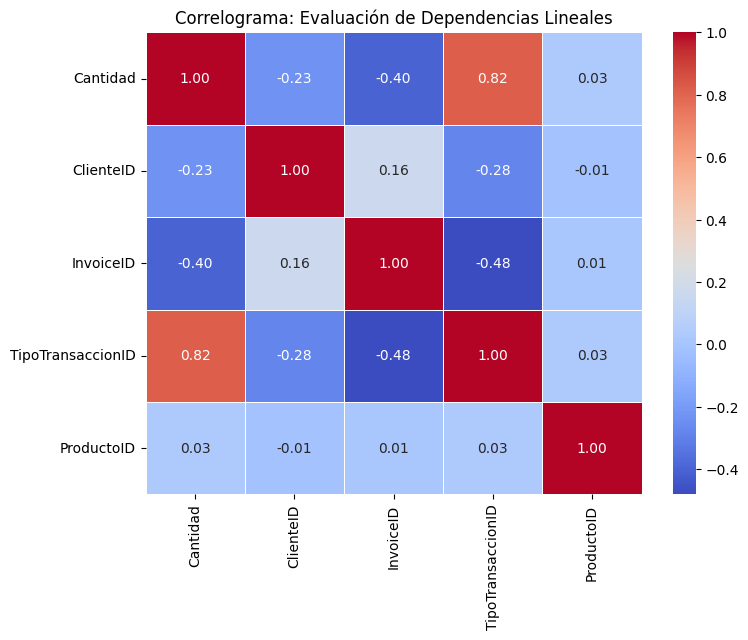

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 

df_muestra = movimientos.sample(withReplacement=False, fraction=0.1, seed=42).toPandas()
columnas_numericas = ['Cantidad', 'ClienteID', 'InvoiceID', 'TipoTransaccionID', 'ProductoID']
df_muestra[columnas_numericas] = df_muestra[columnas_numericas].apply(pd.to_numeric, errors='coerce')

# === 1. CORRELOGRAMA (MAPA DE CALOR) ===
plt.figure(figsize=(8, 6))
matriz_corr = df_muestra[columnas_numericas].corr()

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlograma: Evaluación de Dependencias Lineales')
plt.show()


#### Correlograma
* **El Hallazgo:** La gráfica muestra números muy altos en algunas partes, como un **0.82** entre el `TipoTransaccionID` y la `Cantidad`. Si lo miráramos a ciegas, parecería que están súper relacionados, pero en realidad es una **falsa alarma matemática**.
* **¿Por qué pasa esto?:** * **Los códigos de ID no son números para medir:** Cosas como el `InvoiceID` o el `ClienteID` son solo "etiquetas" o nombres con números. Que la matemática intente sumarlos o buscarles una línea es un error conceptual, porque el número de cédula o de factura no vale más ni menos por ser más alto.
    * **La trampa de los tipos de transacción:** Como pusimos el número `10` para Ventas y `11` para Compras, el algoritmo se confunde. Cree que el `11` es mayor que el `10` y, como el `11` (compras) tiene las cantidades positivas gigantes, se inventa una relación que no existe en la vida real.

* **Conclusión para el trabajo:** Esta gráfica nos sirve para demostrar que **no podemos tratar los códigos de identificación como si fueran números comunes** en los análisis que siguen. Necesitamos tratarlos como categorías independientes (como nombres) para no dañar los futuros modelos.

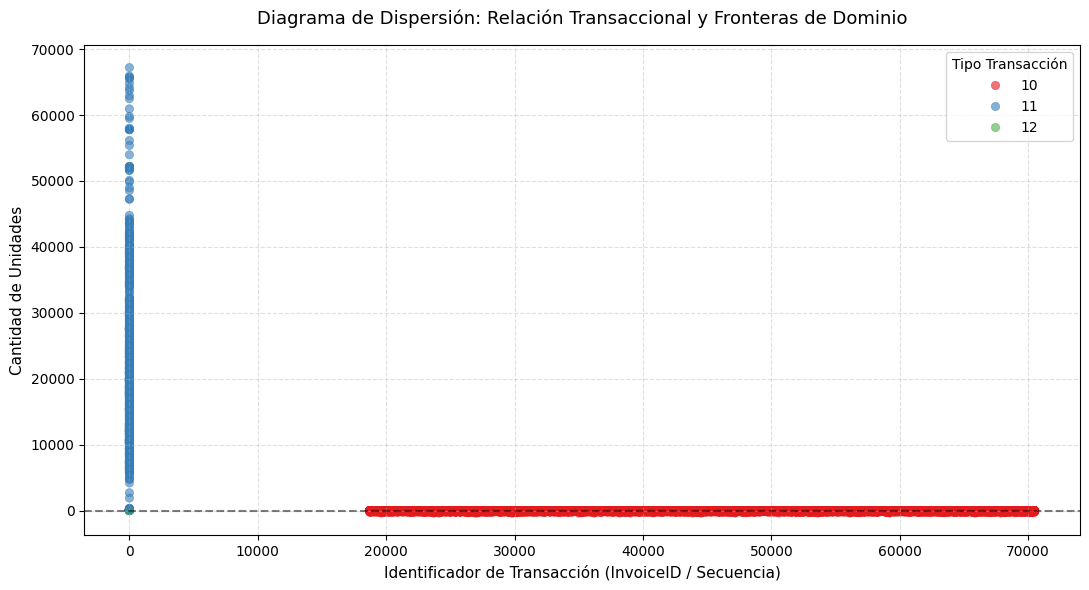

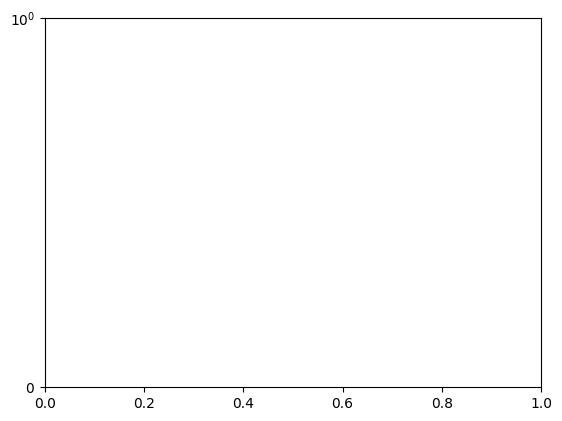

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df_muestra, 
    x='InvoiceID', 
    y='Cantidad', 
    hue='TipoTransaccionID', 
    palette='Set1', 
    alpha=0.6,
    edgecolor=None
)

plt.title('Diagrama de Dispersión: Relación Transaccional y Fronteras de Dominio', fontsize=13, pad=15)
plt.xlabel('Identificador de Transacción (InvoiceID / Secuencia)', fontsize=11)
plt.ylabel('Cantidad de Unidades', fontsize=11)
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Línea guía en cero para ver la frontera
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Tipo Transacción', loc='upper right')

plt.tight_layout()
plt.show()
plt.yscale('symlog')

#### Diagrama de Dispersión
* **¿Qué nos muestra la gráfica?:** Al cruzar el número de factura (`InvoiceID`) con la `Cantidad`, descubrimos que el negocio se divide en dos mundos totalmente separados que no se mezclan entre sí:

    1. **El mundo de las Ventas (Línea Roja):** Es el flujo normal del día a día. Son transacciones continuas que tienen números de factura altos (arrancan desde la 19.000 en adelante). En la gráfica se ve como una línea roja completamente plana pegada al cero, pero sabemos por los datos que en realidad son cantidades negativas (salidas de mercancía de -5 o -9 unidades). Se ve así de plana simplemente porque las compras del otro mundo son gigantescas y "aplastan" visualmente la escala de la gráfica.
    2. **El mundo del Abastecimiento (Puntos Azules y Verdes):** Son las compras grandes para llenar el inventario. Curiosamente, el sistema no les asigna un número de factura (por eso en la gráfica se acumulan todas al principio, en el valor 0 del eje X). Aquí es donde se generan los picos enormes de mercancía que entra, llegando hasta las **67.368 unidades** en un solo movimiento.

* **Conclusión de Calidad de Datos:** La gráfica está perfecta y nos da una tranquilidad enorme. Nos confirma que esos números gigantes de 67.000 unidades no son errores de digitación de un cajero o "ruido" en las ventas comunes. Son movimientos logísticos reales de entrada de mercancía que están bien identificados por el sistema (Tipo 11). 

### Conclusiones

### Reporte Consolidado y Conclusiones del Análisis de Calidad de Datos

**Conclusiones generales:**

1. En la tabla de movimientos tenemos información **relacionada con la operación logística y comercial**, identificando de forma clara los actores (`ClienteID`), las transacciones (`InvoiceID`, `TipoTransaccionID`) y los artículos afectados (`ProductoID`).

2. Una fila de movimientos representa un registro operativo de inventario. Dependiendo de su tipo, puede ser una venta al cliente (salida de mercancía) o un abastecimiento/ajuste en bodega (entrada de producto).

3. **Pregunta para el negocio:** ¿Cuál es el motivo o la regla en el sistema transaccional para que las operaciones de tipo 11 y 12 no generen o no registren un `InvoiceID` como sí lo hace de forma estricta el tipo 10?

---

**Conclusiones de reglas de negocio:**

1. La hipótesis de que el set de datos representa únicamente el flujo comercial tradicional de la empresa no es completamente cierta. Coexisten tipos de transacciones netamente logísticas (Tipo 11 y 12) que rompen la lógica de ventas al registrar cantidades positivas masivas. Es clave aclarar con los dueños del proceso la naturaleza operativa de estos movimientos.

2. Hay un **14.99%** de registros duplicados exactos en la tabla (30.633 filas espejo). PSe propone eliminarlos usando en la etapa de preprocesamiento.

3. La regla de negocio implícita asume que las cantidades de producto manejadas en el día a día son pequeñas y controladas; sin embargo, encontramos un registro con un volumen extremo de **67.368 unidades**. ¿Este valor representa una compra macro real o es un error de digitación en el inventario?

---

**Conclusiones de calidad:**

1. **Validez en Cantidad:** El análisis de rangos estadísticos revela que el 75% de los datos se encuentra por debajo de cero (valores negativos con mediana de -9.0), confirmando que el flujo principal son salidas por ventas. Sin embargo, el valor máximo de **67.368** actúa como un outlier extremo que altera las métricas de tendencia central y la media.

2. **Consistencia Temática y de Contenido:** Al cruzar los identificadores, se detecta que las columnas `InvoiceID` y `ClienteID` presentan valores vacíos o nulos mapeados como 0.0 exclusivamente cuando el `TipoTransaccionID` es 11 o 12. No hay fallas de consistencia en el formato de fechas, registrando 0 errores en su conversión.

3. **Validación de Clientes:** No existen registros erróneos con identificadores de cliente negativos (`ClienteID < 0`), cumpliendo a cabalidad con la regla de integridad esperada para llaves de negocio.

---

**Usando herramientas (Perfilamiento Visual):**

**Sección de Dispersión (Relación Transaccional):**
1. Al graficar `InvoiceID` contra `Cantidad`, el perfilamiento visual revela de forma contundente que el set de datos está dividido en **dos mundos totalmente separados** que no se mezclan:
   * **El bloque comercial (Tipo 10 - Rojo):** Tiene facturas reales (secuencia desde ~19.000 hasta 70.000) y se mantiene estrictamente por debajo de cero, validando visualmente el comportamiento correcto de las ventas.

   * **El bloque logístico (Tipos 11 y 12 - Azul/Verde):** No tiene número de factura (acumulados en el 0 del eje X) y es el único lugar de la base de datos donde se disparan los picos masivos y positivos de mercancía.

2. Gracias a este gráfico se concluye que no se debe borrar el outlier de 67.368 a ciegas, sino que la estrategia correcta de limpieza es **separar o segmentar la analítica de compras de la de ventas** para no contaminar las predicciones comerciales.

**Sección de Correlación:**

3. La matriz de correlación automática muestra un número falsamente alto de **0.82** entre `TipoTransaccionID` y `Cantidad`. Esto es un **artefacto estadístico** (falsa alarma): el algoritmo se confunde porque usamos números (10 y 11) para identificar categorías, asumiendo erróneamente que el tipo 11 "vale más" en la escala matemática.

4. La correlación de **-0.40** entre `InvoiceID` y `Cantidad` tampoco es una relación matemática de negocio. Responde puramente al sesgo del sistema donde las compras grandes carecen de número de factura y se ubican en el cero del gráfico. Se ratifica que las llaves e identificadores categóricos no deben tratarse con correlaciones lineales comunes en los próximos modelos.

## Cierre

Completado este tutorial ya sabrá la forma básica de utilizar PySpark. Ya sabe cómo crear DataFrames a partir de datos existentes, cómo seleccionar columnas o filas de este Dataframe, cómo rellenar espacios vacíos, cómo aplicar sus propias funciones a estos datos y los más importante, cómo utilizarlo para realizar una fase de entendimiento de datos.

Las tablas detallesOrdenesCopia y OrdenesCopia estaran disponibles en caso de que desee repetir este tutorial cuantas veces considere necesario

## 7. Información adicional

Si quiere conocer más sobre PySpark la guía más detallada es la documentación oficial, la cual puede encontrar acá: https://spark.apache.org/docs/latest/api/python/index.html <br>
Para ir directamente a la documentación de PySpark SQL, donde está la información sobre los DataFrames: https://spark.apache.org/docs/latest/api/python/pyspark.sql.html <br>

El Capítulo 2 del libro <i>Learn PySpark : Build Python-based Machine Learning and Deep Learning Models, New York: Apress. 2019</i> de Pramod Singh contiene muchos ejemplos útiles, puede encontrarlo en la biblioteca virtual de la universidad.

## 8. Preguntas frecuentes

1. Si en el cálculo de los histogramas o en una de sus UDF obtiene el error: TypeError: unsupported operand type(s) for *: 'decimal.Decimal' and 'float' verifique los tipos de las columnas que está intentando operar y, si alguna es double, conviértala a float.

2. En algunos casos, encontrará también información sobre <i>Pandas_UDF</i>. <i>Pandas_UDF</i> son también User Defined Functions, por lo general los Pandas UDF son más eficientes que los UDF tradicionales, sin embargo, hay un bug con la versión de PySpark y de Java que se está usando, lo que previene la utilización de Pandas_UDF.

3. Si al ejecutar la configuración de la sesión Spark le aparece el error <i>Cannot run multiple SparkContexts at once; existing SparkContext(app=pyspark-shell, master=local[*])</i> Reinicie el kernel y vuelva a ejecutar
